Purpose: 
Build modelled inequality evidence by combining harmonised borough outcomes, determinants, ethnicity population structure, service experience context, and national disparity baselines.

In [2]:
# Imports and display
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

In [3]:
# Project path
PROJECT_DIR = Path.cwd()
print(f"Current working directory: {PROJECT_DIR}")

Current working directory: c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities


In [4]:
# Input file registry from Notebook 10B
INPUT_FILES = {
    "census_population": PROJECT_DIR / "_harmonised_census_population.parquet",
    "gpps_ethnicity": PROJECT_DIR / "_harmonised_gpps_ethnicity.parquet",
    "gpps_experience": PROJECT_DIR / "_harmonised_gpps_experience.parquet",
    "ons_births": PROJECT_DIR / "_harmonised_ons_births.parquet",
    "fingertips": PROJECT_DIR / "_harmonised_fingertips.parquet",
    "gla": PROJECT_DIR / "_harmonised_gla.parquet",
    "nwl_boroughs": PROJECT_DIR / "_config_nwl_boroughs.csv",
}

In [5]:
# File existence check
file_check_rows = []

for file_name, file_path in INPUT_FILES.items():
    file_check_rows.append(
        {
            "file_name": file_name,
            "path": str(file_path),
            "exists": file_path.exists(),
        }
    )

file_check_df = pd.DataFrame(file_check_rows).sort_values("file_name").reset_index(drop=True)
file_check_df

,file_name,path,exists
0,census_population,c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_harmonis...,True
1,fingertips,c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_harmonis...,True
2,gla,c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_harmonis...,True
3,gpps_ethnicity,c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_harmonis...,True
4,gpps_experience,c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_harmonis...,True
5,nwl_boroughs,c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_config_n...,True
6,ons_births,c:\Users\OlenaManziuk\OneDrive - Third Sector Together North West London\Documents\nwl_health_inequalities\_harmonis...,True


In [6]:
# Load harmonised inputs
try:
    df_census_population = pd.read_parquet(INPUT_FILES["census_population"])
    df_gpps_ethnicity = pd.read_parquet(INPUT_FILES["gpps_ethnicity"])
    df_gpps_experience = pd.read_parquet(INPUT_FILES["gpps_experience"])
    df_ons_births = pd.read_parquet(INPUT_FILES["ons_births"])
    df_fingertips = pd.read_parquet(INPUT_FILES["fingertips"])
    df_gla = pd.read_parquet(INPUT_FILES["gla"])
    df_nwl_boroughs = pd.read_csv(INPUT_FILES["nwl_boroughs"])
except Exception as exc:
    raise RuntimeError(f"Error loading one or more input files: {exc}") from exc

loaded_datasets = {
    "census_population": df_census_population,
    "gpps_ethnicity": df_gpps_ethnicity,
    "gpps_experience": df_gpps_experience,
    "ons_births": df_ons_births,
    "fingertips": df_fingertips,
    "gla": df_gla,
    "nwl_boroughs": df_nwl_boroughs,
}

print("Datasets loaded successfully.")


Datasets loaded successfully.


In [7]:
# Dataset shape and column audit
audit_rows = []

for dataset_name, dataset_df in loaded_datasets.items():
    try:
        audit_rows.append(
            {
                "dataset_name": dataset_name,
                "rows": dataset_df.shape[0],
                "columns": dataset_df.shape[1],
                "column_names": list(dataset_df.columns),
            }
        )
    except Exception as exc:
        audit_rows.append(
            {
                "dataset_name": dataset_name,
                "rows": np.nan,
                "columns": np.nan,
                "column_names": [f"ERROR: {exc}"],
            }
        )

dataset_audit_df = (
    pd.DataFrame(audit_rows)
    .sort_values("dataset_name")
    .reset_index(drop=True)
)

dataset_audit_df


,dataset_name,rows,columns,column_names
0,census_population,64,15,"[table, source, year, geography, area_geography, area_code, area_name, category, metric, analytical_ethnicity, ethni..."
1,fingertips,5112,12,"[table, source, geography, area_geography, area_code, area_name, area_type, time_period, category, metric, measure_r..."
2,gla,888,11,"[table, source, geography, area_geography, area_code, area_name, time_period, category, metric, measure_raw, value]"
3,gpps_ethnicity,252,13,"[table, source, year, geography, area_geography, area_code, area_name, category, metric, ethnicity_raw, ethnicity_st..."
4,gpps_experience,630,12,"[table, source, year, geography, area_geography, area_code, area_name, category, metric, response_category, measure_..."
5,nwl_boroughs,8,2,"[borough, gss_code]"
6,ons_births,995,14,"[table, source, year, geography, area_geography, area_code, area_name, category_group, category, metric, ethnicity_r..."


In [8]:
#Required column presence check
REQUIRED_COLUMNS = {
    "census_population": [
        "table",
        "source",
        "year",
        "geography",
        "area_geography",
        "area_code",
        "area_name",
        "category",
        "metric",
        "value",
        "ethnicity_standard",
    ],
    "fingertips": [
        "table",
        "source",
        "time_period",
        "geography",
        "area_geography",
        "area_code",
        "area_name",
        "category",
        "metric",
        "measure_raw",
        "value",
    ],
    "gla": [
        "table",
        "source",
        "time_period",
        "geography",
        "area_geography",
        "area_code",
        "area_name",
        "category",
        "metric",
        "measure_raw",
        "value",
    ],
    "gpps_ethnicity": [
        "table",
        "source",
        "year",
        "geography",
        "area_geography",
        "area_code",
        "area_name",
        "category",
        "metric",
        "ethnicity_standard",
        "value",
    ],
    "gpps_experience": [
        "table",
        "source",
        "year",
        "geography",
        "area_geography",
        "area_code",
        "area_name",
        "category",
        "metric",
        "measure_raw",
        "value",
    ],
    "ons_births": [
        "table",
        "source",
        "year",
        "geography",
        "area_geography",
        "area_code",
        "area_name",
        "category",
        "metric",
        "ethnicity_standard",
        "value",
    ],
    "nwl_boroughs": [
        "borough",
        "gss_code",
    ],
}

required_column_rows = []

for dataset_name, required_cols in REQUIRED_COLUMNS.items():
    dataset_df = loaded_datasets[dataset_name]
    dataset_columns = set(dataset_df.columns)

    missing_columns = [col for col in required_cols if col not in dataset_columns]

    required_column_rows.append(
        {
            "dataset_name": dataset_name,
            "required_column_count": len(required_cols),
            "missing_column_count": len(missing_columns),
            "missing_columns": missing_columns,
            "all_required_present": len(missing_columns) == 0,
        }
    )

required_columns_check_df = (
    pd.DataFrame(required_column_rows)
    .sort_values("dataset_name")
    .reset_index(drop=True)
)

required_columns_check_df

,dataset_name,required_column_count,missing_column_count,missing_columns,all_required_present
0,census_population,11,0,[],True
1,fingertips,11,0,[],True
2,gla,11,0,[],True
3,gpps_ethnicity,11,0,[],True
4,gpps_experience,11,0,[],True
5,nwl_boroughs,2,0,[],True
6,ons_births,11,0,[],True


In [9]:
# Geography role audit
EXPECTED_GEOGRAPHY = {
    "census_population": "Borough",
    "fingertips": "Borough",
    "gla": "Borough",
    "gpps_ethnicity": "ICS",
    "gpps_experience": "ICS",
    "ons_births": "Country",
}

geography_audit_rows = []

for dataset_name, expected_geography in EXPECTED_GEOGRAPHY.items():
    dataset_df = loaded_datasets[dataset_name]

    observed_geographies = sorted(
        dataset_df["area_geography"].dropna().astype(str).unique().tolist()
    )

    geography_audit_rows.append(
        {
            "dataset_name": dataset_name,
            "expected_area_geography": expected_geography,
            "observed_area_geography": observed_geographies,
            "matches_expected": observed_geographies == [expected_geography],
            "unique_area_names": dataset_df["area_name"].nunique(dropna=True),
            "unique_area_codes": dataset_df["area_code"].nunique(dropna=True),
            "sample_area_names": sorted(
                dataset_df["area_name"].dropna().astype(str).unique().tolist()
            )[:10],
        }
    )

geography_audit_df = (
    pd.DataFrame(geography_audit_rows)
    .sort_values("dataset_name")
    .reset_index(drop=True)
)

geography_audit_df

,dataset_name,expected_area_geography,observed_area_geography,matches_expected,unique_area_names,unique_area_codes,sample_area_names
0,census_population,Borough,[Borough],True,8,8,"[Brent, Ealing, Hammersmith and Fulham, Harrow, Hillingdon, Hounslow, Kensington and Chelsea, Westminster]"
1,fingertips,Borough,[Borough],True,8,8,"[Brent, Ealing, Hammersmith and Fulham, Harrow, Hillingdon, Hounslow, Kensington and Chelsea, Westminster]"
2,gla,Borough,[Borough],True,8,8,"[Brent, Ealing, Hammersmith and Fulham, Harrow, Hillingdon, Hounslow, Kensington and Chelsea, Westminster]"
3,gpps_ethnicity,ICS,[ICS],True,42,42,"[BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM, BEDFORDSHIRE, LUTON AND MILTON KEYNES I..."
4,gpps_experience,ICS,[ICS],True,42,42,"[BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM, BEDFORDSHIRE, LUTON AND MILTON KEYNES I..."
5,ons_births,Country,[Country],True,1,1,[ENGLAND AND WALES]


In [10]:
# NWL borough reference
nwl_borough_reference_df = (
    df_nwl_boroughs[["borough", "gss_code"]]
    .drop_duplicates()
    .sort_values(["borough", "gss_code"])
    .reset_index(drop=True)
)

nwl_borough_reference_df

,borough,gss_code
0,Brent,E09000005
1,Ealing,E09000009
2,Hammersmith and Fulham,E09000013
3,Harrow,E09000015
4,Hillingdon,E09000017
5,Hounslow,E09000018
6,Kensington and Chelsea,E09000020
7,Westminster,E09000033


In [11]:
#Borough coverage check
borough_level_datasets = [
    "census_population",
    "fingertips",
    "gla",
]

reference_borough_df = df_nwl_boroughs.copy()

reference_borough_df["borough"] = (
    reference_borough_df["borough"].astype(str).str.strip()
)
reference_borough_df["gss_code"] = (
    reference_borough_df["gss_code"].astype(str).str.strip()
)

reference_borough_names = set(reference_borough_df["borough"].dropna().unique())
reference_borough_codes = set(reference_borough_df["gss_code"].dropna().unique())

borough_coverage_rows = []

for dataset_name in borough_level_datasets:
    dataset_df = loaded_datasets[dataset_name].copy()

    dataset_df["area_name"] = dataset_df["area_name"].astype(str).str.strip()
    dataset_df["area_code"] = dataset_df["area_code"].astype(str).str.strip()

    dataset_area_names = set(dataset_df["area_name"].dropna().unique())
    dataset_area_codes = set(dataset_df["area_code"].dropna().unique())

    missing_borough_names = sorted(reference_borough_names - dataset_area_names)
    extra_borough_names = sorted(dataset_area_names - reference_borough_names)

    missing_borough_codes = sorted(reference_borough_codes - dataset_area_codes)
    extra_borough_codes = sorted(dataset_area_codes - reference_borough_codes)

    borough_coverage_rows.append(
        {
            "dataset_name": dataset_name,
            "matches_reference_names": (
                len(missing_borough_names) == 0 and len(extra_borough_names) == 0
            ),
            "matches_reference_codes": (
                len(missing_borough_codes) == 0 and len(extra_borough_codes) == 0
            ),
            "missing_borough_names": missing_borough_names,
            "extra_borough_names": extra_borough_names,
            "missing_borough_codes": missing_borough_codes,
            "extra_borough_codes": extra_borough_codes,
        }
    )

borough_coverage_df = (
    pd.DataFrame(borough_coverage_rows)
    .sort_values("dataset_name")
    .reset_index(drop=True)
)

borough_coverage_df


,dataset_name,matches_reference_names,matches_reference_codes,missing_borough_names,extra_borough_names,missing_borough_codes,extra_borough_codes
0,census_population,True,True,[],[],[],[]
1,fingertips,True,True,[],[],[],[]
2,gla,True,True,[],[],[],[]


In [12]:
# Standardise borough keys in borough-level datasets
# Purpose: create clean, merge-ready borough tables for modelling inputs.
borough_level_frames = {
    "census_population": df_census_population.copy(),
    "fingertips": df_fingertips.copy(),
    "gla": df_gla.copy(),
}

standardised_borough_frames = {}

for dataset_name, dataset_df in borough_level_frames.items():
    dataset_df["area_name"] = dataset_df["area_name"].astype(str).str.strip()
    dataset_df["area_code"] = dataset_df["area_code"].astype(str).str.strip()
    dataset_df["area_geography"] = dataset_df["area_geography"].astype(str).str.strip()

    if "year" in dataset_df.columns:
        dataset_df["year"] = dataset_df["year"].astype(str).str.strip()

    if "time_period" in dataset_df.columns:
        dataset_df["time_period"] = dataset_df["time_period"].astype(str).str.strip()

    if "metric" in dataset_df.columns:
        dataset_df["metric"] = dataset_df["metric"].astype(str).str.strip()

    if "category" in dataset_df.columns:
        dataset_df["category"] = dataset_df["category"].astype(str).str.strip()

    if "measure_raw" in dataset_df.columns:
        dataset_df["measure_raw"] = dataset_df["measure_raw"].astype(str).str.strip()

    standardised_borough_frames[dataset_name] = dataset_df

df_census_population_std = standardised_borough_frames["census_population"]
df_fingertips_std = standardised_borough_frames["fingertips"]
df_gla_std = standardised_borough_frames["gla"]

standardised_key_summary_df = pd.DataFrame(
    [
        {
            "dataset_name": dataset_name,
            "unique_area_names": dataset_df["area_name"].nunique(dropna=True),
            "unique_area_codes": dataset_df["area_code"].nunique(dropna=True),
            "sample_area_codes": sorted(
                dataset_df["area_code"].dropna().unique().tolist()
            )[:10],
        }
        for dataset_name, dataset_df in standardised_borough_frames.items()
    ]
).sort_values("dataset_name").reset_index(drop=True)

standardised_key_summary_df


,dataset_name,unique_area_names,unique_area_codes,sample_area_codes
0,census_population,8,8,"[E09000005, E09000009, E09000013, E09000015, E09000017, E09000018, E09000020, E09000033]"
1,fingertips,8,8,"[E09000005, E09000009, E09000013, E09000015, E09000017, E09000018, E09000020, E09000033]"
2,gla,8,8,"[E09000005, E09000009, E09000013, E09000015, E09000017, E09000018, E09000020, E09000033]"


In [13]:
# Inspect time fields across modelling datasets
# Purpose: confirm which datasets use year and which use time_period before creating a common modelling time field.
# We now proceed with Time field audit
time_audit_rows = []

time_datasets = {
    "census_population": df_census_population_std,
    "fingertips": df_fingertips_std,
    "gla": df_gla_std,
    "gpps_ethnicity": df_gpps_ethnicity.copy(),
    "gpps_experience": df_gpps_experience.copy(),
    "ons_births": df_ons_births.copy(),
}

for dataset_name, dataset_df in time_datasets.items():
    year_present = "year" in dataset_df.columns
    time_period_present = "time_period" in dataset_df.columns

    year_sample = []
    time_period_sample = []

    if year_present:
        year_sample = sorted(
            dataset_df["year"].dropna().astype(str).str.strip().unique().tolist()
        )[:10]

    if time_period_present:
        time_period_sample = sorted(
            dataset_df["time_period"].dropna().astype(str).str.strip().unique().tolist()
        )[:10]

    time_audit_rows.append(
        {
            "dataset_name": dataset_name,
            "has_year": year_present,
            "has_time_period": time_period_present,
            "year_sample": year_sample,
            "time_period_sample": time_period_sample,
        }
    )

time_audit_df = (
    pd.DataFrame(time_audit_rows)
    .sort_values("dataset_name")
    .reset_index(drop=True)
)

time_audit_df

,dataset_name,has_year,has_time_period,year_sample,time_period_sample
0,census_population,True,False,[2021],[]
1,fingertips,False,True,[],"[2011/12, 2012, 2012/13, 2013, 2013/14, 2014, 2014/15, 2015, 2015 - 19, 2015/16]"
2,gla,False,True,[],"[2006, 2006/07, 2007, 2007/08, 2008, 2008/09, 2009, 2009/10, 2010, 2010/11]"
3,gpps_ethnicity,True,False,[2025],[]
4,gpps_experience,True,False,[2025],[]
5,ons_births,True,False,"[2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]",[]


In [14]:
# Create modelling time fields
df_census_population_std = df_census_population_std.copy()
df_fingertips_std = df_fingertips_std.copy()
df_gla_std = df_gla_std.copy()

# Census population: source already uses year
df_census_population_std["model_time"] = (
    df_census_population_std["year"].astype(str).str.strip()
)
df_census_population_std["model_year"] = pd.to_numeric(
    df_census_population_std["model_time"],
    errors="coerce",
)

# Fingertips: source uses time_period
df_fingertips_std["model_time"] = (
    df_fingertips_std["time_period"].astype(str).str.strip()
)
df_fingertips_std["model_year"] = pd.to_numeric(
    df_fingertips_std["model_time"].str.extract(r"(\d{4})")[0],
    errors="coerce",
)

# GLA: source uses time_period
df_gla_std["model_time"] = (
    df_gla_std["time_period"].astype(str).str.strip()
)
df_gla_std["model_year"] = pd.to_numeric(
    df_gla_std["model_time"].str.extract(r"(\d{4})")[0],
    errors="coerce",
)

model_time_summary_df = pd.DataFrame(
    [
        {
            "dataset_name": "census_population",
            "rows": len(df_census_population_std),
            "null_model_time": df_census_population_std["model_time"].isna().sum(),
            "null_model_year": df_census_population_std["model_year"].isna().sum(),
            "sample_model_time": sorted(
                df_census_population_std["model_time"]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )[:10],
        },
        {
            "dataset_name": "fingertips",
            "rows": len(df_fingertips_std),
            "null_model_time": df_fingertips_std["model_time"].isna().sum(),
            "null_model_year": df_fingertips_std["model_year"].isna().sum(),
            "sample_model_time": sorted(
                df_fingertips_std["model_time"]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )[:10],
        },
        {
            "dataset_name": "gla",
            "rows": len(df_gla_std),
            "null_model_time": df_gla_std["model_time"].isna().sum(),
            "null_model_year": df_gla_std["model_year"].isna().sum(),
            "sample_model_time": sorted(
                df_gla_std["model_time"]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )[:10],
        },
    ]
).sort_values("dataset_name").reset_index(drop=True)

model_time_summary_df

,dataset_name,rows,null_model_time,null_model_year,sample_model_time
0,census_population,64,0,0,[2021]
1,fingertips,5112,0,0,"[2011/12, 2012, 2012/13, 2013, 2013/14, 2014, 2014/15, 2015, 2015 - 19, 2015/16]"
2,gla,888,0,0,"[2006, 2006/07, 2007, 2007/08, 2008, 2008/09, 2009, 2009/10, 2010, 2010/11]"


In [15]:
# Standardise outcomes (Fingertips) into a consistent analytical structure - create borough-level outcomes dataset
df_outcomes = df_fingertips_std.copy()

# Keep only relevant columns for modelling
outcomes_columns = [
    "area_name",
    "area_code",
    "model_time",
    "model_year",
    "category",
    "metric",
    "measure_raw",
    "value",
]

missing_cols = [col for col in outcomes_columns if col not in df_outcomes.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in outcomes dataset: {missing_cols}")

df_outcomes = df_outcomes[outcomes_columns].copy()

# Ensure numeric values
df_outcomes["value"] = pd.to_numeric(df_outcomes["value"], errors="coerce")

# Drop rows with no value
df_outcomes = df_outcomes.dropna(subset=["value"])

# Reset index
df_outcomes = df_outcomes.reset_index(drop=True)

df_outcomes.head()

,area_name,area_code,model_time,model_year,category,metric,measure_raw,value
0,Brent,E09000005,2014/15,2014,NaN,% reporting a long term MSK problem who also report depression or anxiety,value,25.987533
1,Brent,E09000005,2015/16,2015,NaN,% reporting a long term MSK problem who also report depression or anxiety,value,26.395159
2,Brent,E09000005,2016/17,2016,NaN,% reporting a long term MSK problem who also report depression or anxiety,value,23.705820
3,Brent,E09000005,2020,2020,NaN,% reporting a long-term mental health problem,value,6.391032
4,Brent,E09000005,2020,2020,NaN,% reporting cancer in the last 5 years,value,2.793530


In [16]:
# Confirm structure before using it downstream - outcomes dataset summary
outcomes_summary_df = pd.DataFrame(
    {
        "rows": [len(df_outcomes)],
        "unique_boroughs": [df_outcomes["area_name"].nunique()],
        "unique_metrics": [df_outcomes["metric"].nunique()],
        "unique_categories": [df_outcomes["category"].nunique()],
        "min_year": [df_outcomes["model_year"].min()],
        "max_year": [df_outcomes["model_year"].max()],
        "null_values": [df_outcomes["value"].isna().sum()],
    }
)

outcomes_summary_df


,rows,unique_boroughs,unique_metrics,unique_categories,min_year,max_year,null_values
0,4459,8,28,5,2011,2024,0


In [17]:
# Create borough-level determinants dataset
# Align GLA data into the same analytical structure as outcomes
df_determinants = df_gla_std.copy()

determinants_columns = [
    "area_name",
    "area_code",
    "model_time",
    "model_year",
    "category",
    "metric",
    "measure_raw",
    "value",
]

missing_cols = [col for col in determinants_columns if col not in df_determinants.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in determinants dataset: {missing_cols}")

df_determinants = df_determinants[determinants_columns].copy()

# Ensure numeric
df_determinants["value"] = pd.to_numeric(df_determinants["value"], errors="coerce")

# Drop empty values
df_determinants = df_determinants.dropna(subset=["value"])

df_determinants = df_determinants.reset_index(drop=True)

df_determinants.head()

,area_name,area_code,model_time,model_year,category,metric,measure_raw,value
0,Brent,E09000005,2011 - 13,2011,Wider determinants,1. HLE male,value,62.64
1,Brent,E09000005,2011 - 13,2011,Wider determinants,1. HLE male,value,62.64
2,Brent,E09000005,2012 - 14,2012,Wider determinants,1. HLE male,value,64.33
3,Brent,E09000005,2012 - 14,2012,Wider determinants,1. HLE male,value,64.33
4,Brent,E09000005,2013 - 15,2013,Wider determinants,1. HLE male,value,63.71


In [18]:
# Determinants dataset summary
determinants_summary_df = pd.DataFrame(
    {
        "rows": [len(df_determinants)],
        "unique_boroughs": [df_determinants["area_name"].nunique()],
        "unique_metrics": [df_determinants["metric"].nunique()],
        "unique_categories": [df_determinants["category"].nunique()],
        "min_year": [df_determinants["model_year"].min()],
        "max_year": [df_determinants["model_year"].max()],
        "null_values": [df_determinants["value"].isna().sum()],
    }
)

determinants_summary_df

,rows,unique_boroughs,unique_metrics,unique_categories,min_year,max_year,null_values
0,866,8,11,1,2006,2023,0


In [72]:
# Create ethnicity population baseline - build borough × ethnicity population structure
df_population = df_census_population_std.copy()

population_columns = [
    "area_name",
    "area_code",
    "category",  # typically age or grouping
    "metric",
    "ethnicity_standard",
    "value",
]

missing_cols = [col for col in population_columns if col not in df_population.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in population dataset: {missing_cols}")

df_population = df_population[population_columns].copy()

# Ensure numeric
df_population["value"] = pd.to_numeric(df_population["value"], errors="coerce")

# Drop nulls
df_population = df_population.dropna(subset=["value", "ethnicity_standard"])

# Standardise ethnicity
df_population["ethnicity_standard"] = (
    df_population["ethnicity_standard"].astype(str).str.strip()
)

df_population = df_population.reset_index(drop=True)

df_population.head()

,area_name,area_code,category,metric,ethnicity_standard,value
0,Brent,E09000005,Population,population_count,Asian,111515
1,Brent,E09000005,Population,population_count,Black,31070
2,Brent,E09000005,Population,population_count,Black,21258
3,Brent,E09000005,Population,population_count,Black,7167
4,Brent,E09000005,Population,population_count,Mixed,17249


In [20]:
# Population baseline summary
population_summary_df = pd.DataFrame(
    {
        "rows": [len(df_population)],
        "unique_boroughs": [df_population["area_name"].nunique()],
        "unique_ethnicities": [df_population["ethnicity_standard"].nunique()],
        "ethnicity_groups": [
            sorted(df_population["ethnicity_standard"].unique().tolist())
        ],
        "total_population": [df_population["value"].sum()],
        "null_values": [df_population["value"].isna().sum()],
    }
)

population_summary_df

,rows,unique_boroughs,unique_ethnicities,ethnicity_groups,total_population,null_values
0,64,8,5,"[Asian, Black, Mixed, Other, White]",2092995,0


Because ethnicity_standard = Black appears multiple times per borough we need to aggregate population that is currently represented by sub-groups


In [21]:
# Aggregate population
df_population_agg = (
    df_population
    .groupby(
        ["area_name", "area_code", "ethnicity_standard"],
        as_index=False
    )["value"]
    .sum()
)

df_population_agg = df_population_agg.rename(
    columns={"value": "population"}
)

df_population_agg.head()

,area_name,area_code,ethnicity_standard,population
0,Brent,E09000005,Asian,111515
1,Brent,E09000005,Black,59495
2,Brent,E09000005,Mixed,17249
3,Brent,E09000005,Other,33861
4,Brent,E09000005,White,117701


In [22]:
# Population proportion by ethnicity
# Enable comparable ethnicity structure across boroughs
df_population_prop = df_population_agg.copy()

# Total population per borough
borough_totals = (
    df_population_prop
    .groupby("area_code")["population"]
    .sum()
    .rename("total_population")
    .reset_index()
)

df_population_prop = df_population_prop.merge(
    borough_totals,
    on="area_code",
    how="left"
)

# Calculate proportion
df_population_prop["population_proportion"] = (
    df_population_prop["population"] / df_population_prop["total_population"]
)

df_population_prop.head()

,area_name,area_code,ethnicity_standard,population,total_population,population_proportion
0,Brent,E09000005,Asian,111515,339821,0.328158
1,Brent,E09000005,Black,59495,339821,0.175077
2,Brent,E09000005,Mixed,17249,339821,0.050759
3,Brent,E09000005,Other,33861,339821,0.099644
4,Brent,E09000005,White,117701,339821,0.346362


In [23]:
# Population validation
population_validation_df = (
    df_population_prop
    .groupby("area_name")["population_proportion"]
    .sum()
    .reset_index()
)

population_validation_df

,area_name,population_proportion
0,Brent,1.0
1,Ealing,1.0
2,Hammersmith and Fulham,1.0
3,Harrow,1.0
4,Hillingdon,1.0
5,Hounslow,1.0
6,Kensington and Chelsea,1.0
7,Westminster,1.0


In [24]:
# Prepare GPPS experience dataset (ICS context)
df_experience = df_gpps_experience.copy()

experience_columns = [
    "area_name",
    "area_code",
    "year",
    "category",
    "metric",
    "response_category",
    "measure_raw",
    "value",
]

missing_cols = [col for col in experience_columns if col not in df_experience.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in experience dataset: {missing_cols}")

df_experience = df_experience[experience_columns].copy()

# Clean fields
df_experience["area_name"] = df_experience["area_name"].astype(str).str.strip()
df_experience["area_code"] = df_experience["area_code"].astype(str).str.strip()
df_experience["year"] = df_experience["year"].astype(str).str.strip()
df_experience["value"] = pd.to_numeric(df_experience["value"], errors="coerce")

df_experience = df_experience.dropna(subset=["value"])

df_experience = df_experience.reset_index(drop=True)

df_experience.head()


,area_name,area_code,year,category,metric,response_category,measure_raw,value
0,"BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM",QOX,2025,Service experience,gpcontactoverall,1,gpcontactoverall_1.pct,0.450732
1,"BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM",QOX,2025,Service experience,gpcontactoverall,2,gpcontactoverall_2.pct,0.297158
2,"BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM",QOX,2025,Service experience,gpcontactoverall,3,gpcontactoverall_3.pct,0.122938
3,"BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM",QOX,2025,Service experience,gpcontactoverall,4,gpcontactoverall_4.pct,0.072810
4,"BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM",QOX,2025,Service experience,gpcontactoverall,5,gpcontactoverall_5.pct,0.056361


In [25]:
# Experience dataset summary
experience_summary_df = pd.DataFrame(
    {
        "rows": [len(df_experience)],
        "unique_areas": [df_experience["area_name"].nunique()],
        "unique_metrics": [df_experience["metric"].nunique()],
        "unique_response_categories": [df_experience["response_category"].nunique()],
        "years": [sorted(df_experience["year"].unique().tolist())],
        "null_values": [df_experience["value"].isna().sum()],
    }
)

experience_summary_df

,rows,unique_areas,unique_metrics,unique_response_categories,years,null_values
0,630,42,3,5,[2025],0


In [26]:
# prepare ONS national births dataset (disparity baseline)
df_births = df_ons_births.copy()

births_columns = [
    "year",
    "category",
    "metric",
    "ethnicity_standard",
    "value",
]

missing_cols = [col for col in births_columns if col not in df_births.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in births dataset: {missing_cols}")

df_births = df_births[births_columns].copy()

df_births["year"] = df_births["year"].astype(str).str.strip()
df_births["ethnicity_standard"] = (
    df_births["ethnicity_standard"].astype(str).str.strip()
)
df_births["value"] = pd.to_numeric(df_births["value"], errors="coerce")

df_births = df_births.dropna(subset=["value", "ethnicity_standard"])

df_births = df_births.reset_index(drop=True)

df_births.head()

,year,category,metric,ethnicity_standard,value
0,2007,All,number_live_births,Asian,9249.0
1,2007,All,number_live_births,Asian,18106.0
2,2007,All,number_live_births,Asian,26108.0
3,2007,All,number_live_births,Asian,12587.0
4,2007,All,number_live_births,Black,22399.0


In [27]:
# Births dataset summary
births_summary_df = pd.DataFrame(
    {
        "rows": [len(df_births)],
        "unique_years": [df_births["year"].nunique()],
        "unique_ethnicities": [df_births["ethnicity_standard"].nunique()],
        "ethnicity_groups": [
            sorted(df_births["ethnicity_standard"].unique().tolist())
        ],
        "null_values": [df_births["value"].isna().sum()],
    }
)

births_summary_df

,rows,unique_years,unique_ethnicities,ethnicity_groups,null_values
0,995,16,6,"[Asian, Black, Mixed, Not stated, Other, White]",0


We now have all modelling layers prepared

| Layer             | Dataset              | Role                         |
| ----------------- | -------------------- | ---------------------------- |
| Outcomes          | `df_outcomes`        | what is happening - service-related factors: access, unmet needs, targeted care            |
| Determinants      | `df_determinants`    | why it may be happening - social drivers or structural conditions: housing/employment/environment     |
| Population        | `df_population_prop` | who is affected              |
| Experience        | `df_experience`      | service perception context   |
| National baseline | `df_births`          | external disparity benchmark |



Now we will build the first aligned modelling dataset.

This is the core structure:
→ borough × metric × time × value (outcomes + determinants combined)

In [28]:
#  Combined dataset outcomes + determinants
df_outcomes["data_source"] = "outcome"
df_determinants["data_source"] = "determinant"

common_columns = [
    "area_name",
    "area_code",
    "model_time",
    "model_year",
    "category",
    "metric",
    "measure_raw",
    "value",
    "data_source",
]

df_combined = pd.concat(
    [
        df_outcomes[common_columns],
        df_determinants[common_columns],
    ],
    axis=0,
    ignore_index=True,
)

df_combined = df_combined.reset_index(drop=True)

df_combined.head()

,area_name,area_code,model_time,model_year,category,metric,measure_raw,value,data_source
0,Brent,E09000005,2014/15,2014,NaN,% reporting a long term MSK problem who also report depression or anxiety,value,25.987533,outcome
1,Brent,E09000005,2015/16,2015,NaN,% reporting a long term MSK problem who also report depression or anxiety,value,26.395159,outcome
2,Brent,E09000005,2016/17,2016,NaN,% reporting a long term MSK problem who also report depression or anxiety,value,23.705820,outcome
3,Brent,E09000005,2020,2020,NaN,% reporting a long-term mental health problem,value,6.391032,outcome
4,Brent,E09000005,2020,2020,NaN,% reporting cancer in the last 5 years,value,2.793530,outcome


In [29]:
# Combined dataset summary
combined_summary_df = pd.DataFrame(
    {
        "rows": [len(df_combined)],
        "unique_boroughs": [df_combined["area_name"].nunique()],
        "unique_metrics": [df_combined["metric"].nunique()],
        "data_sources": [df_combined["data_source"].unique().tolist()],
        "min_year": [df_combined["model_year"].min()],
        "max_year": [df_combined["model_year"].max()],
    }
)

combined_summary_df

,rows,unique_boroughs,unique_metrics,data_sources,min_year,max_year
0,5325,8,39,"[outcome, determinant]",2006,2024


In [30]:
# Borough × metric × year grid
try:
    nwl_lookup_df = df_nwl_boroughs.copy()

    nwl_lookup_df["borough"] = (
        nwl_lookup_df["borough"].astype(str).str.strip()
    )
    nwl_lookup_df["gss_code"] = (
        nwl_lookup_df["gss_code"].astype(str).str.strip()
    )

    boroughs = nwl_lookup_df["gss_code"].dropna().unique()
    metrics = df_combined["metric"].dropna().astype(str).str.strip().unique()
    years = df_combined["model_year"].dropna().unique()

    grid = pd.MultiIndex.from_product(
        [boroughs, metrics, years],
        names=["area_code", "metric", "model_year"]
    ).to_frame(index=False)

    grid = grid.merge(
        nwl_lookup_df.rename(columns={"gss_code": "area_code"}),
        on="area_code",
        how="left"
    )

except Exception as exc:
    raise RuntimeError(f"Error creating modelling grid: {exc}") from exc

grid.head()


,area_code,metric,model_year,borough
0,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2014,Brent
1,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2015,Brent
2,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2016,Brent
3,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2020,Brent
4,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2013,Brent


In [31]:
# Align combined dataset to grid
try:
    df_aligned = grid.merge(
        df_combined,
        on=["area_code", "metric", "model_year"],
        how="left"
    )

    # Restore consistent borough naming
    df_aligned["area_name"] = df_aligned["borough"]
    df_aligned = df_aligned.drop(columns=["borough"])

    # Reorder columns
    ordered_columns = [
        "area_name",
        "area_code",
        "metric",
        "model_year",
        "model_time",
        "category",
        "measure_raw",
        "value",
        "data_source",
    ]

    existing_columns = [col for col in ordered_columns if col in df_aligned.columns]
    remaining_columns = [col for col in df_aligned.columns if col not in existing_columns]

    df_aligned = df_aligned[existing_columns + remaining_columns]

    df_aligned = df_aligned.sort_values(
        ["area_code", "metric", "model_year"]
    ).reset_index(drop=True)

except Exception as exc:
    raise RuntimeError(f"Error aligning dataset: {exc}") from exc

df_aligned.head()

,area_name,area_code,metric,model_year,model_time,category,measure_raw,value,data_source
0,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2006,NaN,NaN,NaN,NaN,NaN
1,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2007,NaN,NaN,NaN,NaN,NaN
2,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2008,NaN,NaN,NaN,NaN,NaN
3,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2009,NaN,NaN,NaN,NaN,NaN
4,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2010,NaN,NaN,NaN,NaN,NaN


In [32]:
df_aligned["area_name"].value_counts(dropna=False)

area_name
Brent                     1198
Ealing                    1194
Hillingdon                1180
Hounslow                  1177
Harrow                    1161
Westminster               1107
Hammersmith and Fulham    1098
Kensington and Chelsea    1042
Name: count, dtype: int64

What we are seeing is expected because the grid contains all borough × metric × year combinations, while the source data only contains the combinations that actually exist.

So:

rows with values = observed data

rows with NaN = valid structural gaps made explicit by the grid



This is the first modelling-ready structure:

consistent comparison space

explicit missingness (gaps become visible)

supports:

- trend analysis

- borough comparison

- later modelling (regression, inequality scoring)

The next section measures that missingness clearly before we derive comparison features.

In [33]:
# Data completeness
completeness_df = pd.DataFrame(
    {
        "total_rows": [len(df_aligned)],
        "rows_with_values": [df_aligned["value"].notna().sum()],
        "rows_missing_values": [df_aligned["value"].isna().sum()],
        "coverage_rate": [
            df_aligned["value"].notna().sum() / len(df_aligned)
        ],
    }
)

completeness_df

,total_rows,rows_with_values,rows_missing_values,coverage_rate
0,9157,5325,3832,0.581522


Coverage ~58% is expected given:

- many metrics are not reported every year
- determinants and outcomes have different time spans
- grid enforces full comparability space

This confirms the structure is working correctly.

In [34]:
# Metric availability by borough - check whether some boroughs have systematically lower coverage than others.
availability_df = (
    df_aligned
    .groupby("area_name")
    .agg(
        total_rows=("value", "size"),
        available_values=("value", lambda x: x.notna().sum()),
    )
    .reset_index()
)

availability_df["coverage_rate"] = (
    availability_df["available_values"] / availability_df["total_rows"]
)

availability_df = availability_df.sort_values(
    ["coverage_rate", "area_name"],
    ascending=[False, True]
).reset_index(drop=True)

availability_df

,area_name,total_rows,available_values,coverage_rate
0,Ealing,1194,716,0.599665
1,Brent,1198,718,0.599332
2,Hillingdon,1180,702,0.594915
3,Hounslow,1177,699,0.593883
4,Harrow,1161,683,0.588286
5,Westminster,1107,627,0.566396
6,Hammersmith and Fulham,1098,620,0.564663
7,Kensington and Chelsea,1042,560,0.537428


In [35]:
# Value type classification - separate percentage-style indicators from other numeric indicators before standardisation.
df_aligned["value_type"] = np.where(
    df_aligned["metric"].astype(str).str.contains("%", na=False),
    "percentage",
    "absolute_or_rate"
)

value_type_summary_df = (
    df_aligned["value_type"]
    .value_counts(dropna=False)
    .rename_axis("value_type")
    .reset_index(name="count")
)

value_type_summary_df

,value_type,count
0,absolute_or_rate,8397
1,percentage,760


Approximately 85% of all metrics are absolute_or_rate and 15% - are percentages. 

We will proceed with metric standardisation, where we put different metrics onto the same scale so they can be compared.

In [36]:
# Metric standardisation (z-score) 
df_standardised = df_aligned.copy()

valid_values_mask = df_standardised["value"].notna()

metric_stats = (
    df_standardised.loc[valid_values_mask]
    .groupby("metric")["value"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "metric_mean", "std": "metric_std"})
)

df_standardised = df_standardised.merge(
    metric_stats,
    on="metric",
    how="left"
)

df_standardised["z_score"] = np.where(
    df_standardised["metric_std"].notna() & (df_standardised["metric_std"] != 0),
    (df_standardised["value"] - df_standardised["metric_mean"]) / df_standardised["metric_std"],
    np.nan
)

df_standardised.head()

,area_name,area_code,metric,model_year,model_time,category,measure_raw,value,data_source,value_type,metric_mean,metric_std,z_score
0,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2006,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN
1,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2007,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN
2,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2008,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN
3,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2009,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN
4,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2010,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN


Rows with NaN are missing/unavailable data, preserved for transparancy. 

Z-scores are valid and all metrics are on a common scale 

In [37]:
# Standardisation check
zscore_summary_df = (
    df_standardised["z_score"]
    .describe()
    .to_frame(name="z_score_stats")
)

zscore_summary_df

,z_score_stats
count,5.325000e+03
mean,4.803669e-17
std,9.964249e-01
min,-3.967924e+00
25%,-7.345070e-01
50%,-1.578059e-01
75%,5.993425e-01
max,6.451899e+00


In [38]:
# Borough inequality signal (pre-direction)
borough_inequality_df = (
    df_standardised
    .dropna(subset=["z_score"])
    .groupby("area_name", as_index=False)["z_score"]
    .mean()
    .rename(columns={"z_score": "average_z_score"})
    .sort_values("average_z_score", ascending=False)
    .reset_index(drop=True)
)

borough_inequality_df

,area_name,average_z_score
0,Hammersmith and Fulham,0.146210
1,Brent,0.089667
2,Hounslow,0.029132
3,Westminster,0.003417
4,Ealing,-0.043279
5,Kensington and Chelsea,-0.051352
6,Hillingdon,-0.074442
7,Harrow,-0.095950


We will now proceed with manual definition of all metrics' direction as there are positive and negative metrics, 

e.g. life expectancy (high = good) and high desease burden ( high = bad).

We will define whether 'higher = worse'  or 'higher = better'.

Then flip z-score for 'good' metrics so that higher final score = consistently worse outcome 


In [39]:
# Extract metric list - define the universe we must classify 
metric_list = sorted(df_standardised["metric"].dropna().unique().tolist())

metric_df = pd.DataFrame({"metric": metric_list})

metric_df

,metric
0,% reporting a long term MSK problem who also report depression or anxiety
1,% reporting a long-term mental health problem
2,% reporting cancer in the last 5 years
3,% reporting depression or anxiety
4,% with caring responsibility
5,1. HLE male
6,11. HIV late diagnosis
7,14. Smoking prevalence
8,2. HLE female
9,3. Low Birth Weight


In [40]:
# Metric direction mapping

metric_direction_map = {
    "% reporting a long term MSK problem who also report depression or anxiety": "adverse",
    "% reporting a long-term mental health problem": "adverse",
    "% reporting cancer in the last 5 years": "adverse",
    "% reporting depression or anxiety": "adverse",
    "% with caring responsibility": "positive",
    "1. HLE male": "positive",
    "11. HIV late diagnosis": "adverse",
    "14. Smoking prevalence": "adverse",
    "2. HLE female": "positive",
    "3. Low Birth Weight": "adverse",
    "4. School readiness FSM": "positive",
    "5. Excess weight age 10-11": "adverse",
    "6. Excess weight age 04-05": "adverse",
    "7. Suicide rate": "adverse",
    "8. Mortality caused by PM2.5": "adverse",
    "9. Employment gap LongtermCond.": "adverse",
    "Abdominal Aortic Aneurysm Screening Coverage": "positive",
    "Access rate to specialist perinatal mental health services": "positive",
    "Acute hepatitis B incidence rate/100,000": "adverse",
    "Admission episodes for alcohol-related cardiovascular disease (Broad)": "adverse",
    "Admission episodes for alcohol-related conditions (Broad)": "adverse",
    "Admission episodes for alcohol-related conditions (Narrow) (40 to 64 years)": "adverse",
    "Admission episodes for alcohol-related conditions (Narrow) (65 years and over)": "adverse",
    "Admission episodes for alcohol-related unintentional injuries (Narrow)": "adverse",
    "Admission episodes for alcoholic liver disease (Broad)": "adverse",
    "Alcohol-related conditions: admission episodes (all primary and secondary diagnoses)": "adverse",
    "Asthma: QOF prevalence": "adverse",
    "COPD: QOF prevalence": "adverse",
    "Cancer incidence: lung cancer": "adverse",
    "Chlamydia detection rate per 100,000 aged 15 to 24 years": "adverse",
    "Chlamydia proportion of females aged 15 to 24 years screened": "adverse",
    "Chronic obstructive pulmonary disease (COPD): emergency hospital admissions": "adverse",
    "Diabetes: QOF prevalence": "adverse",
    "Emergency admissions for lower respiratory tract infections (0 to 4 years)": "adverse",
    "Epilepsy: QOF prevalence": "adverse",
    "Estimated diabetes diagnosis rate": "adverse",
    "Estimated prevalence of diagnosed and undiagnosed type 2 diabetes": "adverse",
    "Hospital admissions for diabetes (under 19 years)": "adverse",
    "Hospital admissions for epilepsy (under 19 years)": "adverse",
}

# Convert to dataframe for validation
metric_direction_df = pd.DataFrame(
    list(metric_direction_map.items()),
    columns=["metric", "direction"]
)

metric_direction_df

,metric,direction
0,% reporting a long term MSK problem who also report depression or anxiety,adverse
1,% reporting a long-term mental health problem,adverse
2,% reporting cancer in the last 5 years,adverse
3,% reporting depression or anxiety,adverse
4,% with caring responsibility,positive
5,1. HLE male,positive
6,11. HIV late diagnosis,adverse
7,14. Smoking prevalence,adverse
8,2. HLE female,positive
9,3. Low Birth Weight,adverse


In [41]:
# Mapping coverage check
mapped_metrics = set(metric_direction_df["metric"])
all_metrics = set(metric_list)

missing_metrics = sorted(all_metrics - mapped_metrics)

coverage_check_df = pd.DataFrame({
    "total_metrics": [len(all_metrics)],
    "mapped_metrics": [len(mapped_metrics)],
    "missing_metrics_count": [len(missing_metrics)],
    "missing_metrics": [missing_metrics]
})

coverage_check_df

,total_metrics,mapped_metrics,missing_metrics_count,missing_metrics
0,39,39,0,[]


In [42]:
# Apply metric direction
df_direction = df_standardised.merge(
    metric_direction_df,
    on="metric",
    how="left"
)

# Safety check
if df_direction["direction"].isna().sum() > 0:
    raise ValueError("Some metrics missing direction mapping")

df_direction.head()

,area_name,area_code,metric,model_year,model_time,category,measure_raw,value,data_source,value_type,metric_mean,metric_std,z_score,direction
0,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2006,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse
1,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2007,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse
2,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2008,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse
3,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2009,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse
4,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2010,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse


In [43]:
# Adjust z-score direction
df_direction["adjusted_z_score"] = np.where(
    df_direction["direction"] == "adverse",
    df_direction["z_score"],          # keep as is
    -df_direction["z_score"]          # flip positive metrics
)

df_direction.head()

,area_name,area_code,metric,model_year,model_time,category,measure_raw,value,data_source,value_type,metric_mean,metric_std,z_score,direction,adjusted_z_score
0,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2006,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
1,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2007,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
2,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2008,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
3,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2009,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
4,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2010,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN


In [44]:
# Borough inequality index (direction-adjusted)
borough_inequality_adjusted_df = (
    df_direction
    .dropna(subset=["adjusted_z_score"])
    .groupby("area_name", as_index=False)["adjusted_z_score"]
    .mean()
    .rename(columns={"adjusted_z_score": "inequality_score"})
    .sort_values("inequality_score", ascending=False)
    .reset_index(drop=True)
)

borough_inequality_adjusted_df

,area_name,inequality_score
0,Hounslow,0.147269
1,Hammersmith and Fulham,0.130513
2,Brent,0.113759
3,Ealing,0.034051
4,Westminster,0.008946
5,Hillingdon,-0.033353
6,Harrow,-0.196186
7,Kensington and Chelsea,-0.246640


The above table demonstrates cumulative metric health inequality_score by borough in NW London over the years: 

Higher relative disadvantage - Hounslow, Hammersmith and FulhamBrent - consistently above-average burden across combined indicators

Middle / mixed - Ealing, Westminster - close to average, mixed performance across metrics

Lower relative disadvantage - Hillingdon, Harrow, Kensington and Chelsea - relatively better outcomes overall

Important nuance - this result is:
- unweighted
- multi-metric average
- time-aggregated

So it reflects structural pattern across all available indicators.

But it does NOT yet account for:
- population structure (ethnicity, age)
- differing importance of metrics
- domain differences (health vs determinants)

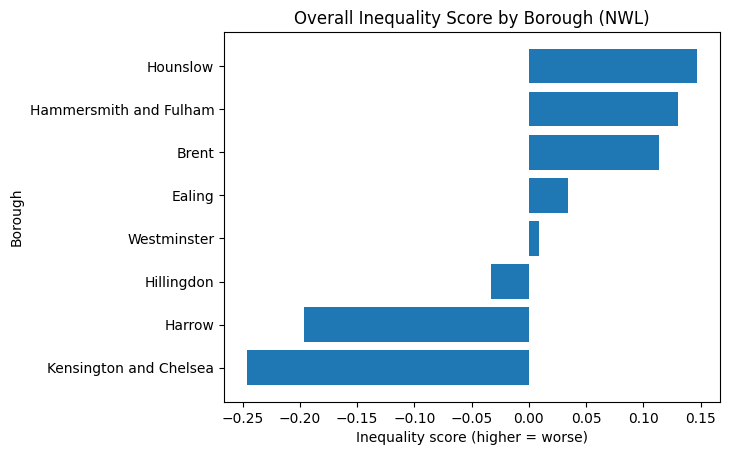

In [45]:
# Quick view of overall inequality ranking - Inequality bar chart
plot_df = borough_inequality_adjusted_df.copy()

plt.figure()
plt.barh(plot_df["area_name"], plot_df["inequality_score"])
plt.xlabel("Inequality score (higher = worse)")
plt.ylabel("Borough")
plt.title("Overall Inequality Score by Borough (NWL)")
plt.gca().invert_yaxis()

plt.show()


Next we will build domain-specific borough indices first, then layer in ethnicity population structure.

In [46]:
# Domain-specific inequality indices
domain_inequality_df = (
    df_direction
    .dropna(subset=["adjusted_z_score", "data_source"])
    .groupby(["area_name", "data_source"], as_index=False)["adjusted_z_score"]
    .mean()
    .rename(columns={"adjusted_z_score": "domain_inequality_score"})
)

domain_inequality_df = domain_inequality_df.sort_values(
    ["data_source", "domain_inequality_score"],
    ascending=[True, False]
).reset_index(drop=True)

domain_inequality_df

,area_name,data_source,domain_inequality_score
0,Hounslow,determinant,0.496094
1,Westminster,determinant,0.293649
2,Brent,determinant,0.289348
3,Ealing,determinant,0.238457
4,Hillingdon,determinant,0.062285
5,Hammersmith and Fulham,determinant,-0.179528
6,Harrow,determinant,-0.487593
7,Kensington and Chelsea,determinant,-0.715137
8,Hammersmith and Fulham,outcome,0.196647
9,Brent,outcome,0.083009


In [47]:
# WE will create one borough-level table for direct comparison.

borough_domain_profile_df = (
    domain_inequality_df
    .pivot(
        index="area_name",
        columns="data_source",
        values="domain_inequality_score"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

borough_domain_profile_df = borough_domain_profile_df.rename(
    columns={
        "outcome": "outcome_inequality_score",
        "determinant": "determinant_inequality_score",
    }
)

borough_domain_profile_df = borough_domain_profile_df.merge(
    borough_inequality_adjusted_df,
    on="area_name",
    how="left"
)

borough_domain_profile_df = borough_domain_profile_df.sort_values(
    "inequality_score",
    ascending=False
).reset_index(drop=True)

borough_domain_profile_df

,area_name,determinant_inequality_score,outcome_inequality_score,inequality_score
0,Hounslow,0.496094,0.082825,0.147269
1,Hammersmith and Fulham,-0.179528,0.196647,0.130513
2,Brent,0.289348,0.083009,0.113759
3,Ealing,0.238457,-0.002655,0.034051
4,Westminster,0.293649,-0.049637,0.008946
5,Hillingdon,0.062285,-0.050932,-0.033353
6,Harrow,-0.487593,-0.140849,-0.196186
7,Kensington and Chelsea,-0.715137,-0.135980,-0.246640


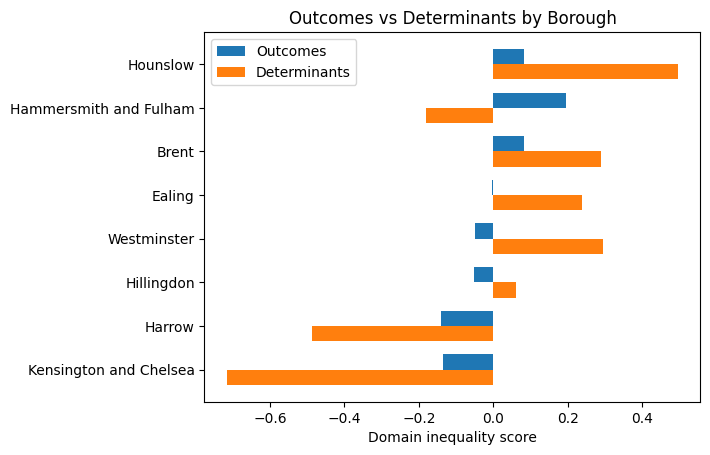

In [48]:
# Plot - plot Outcomes vs Determinants
plot_df = borough_domain_profile_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure()

plt.barh(x - width/2, plot_df["outcome_inequality_score"], height=width, label="Outcomes")
plt.barh(x + width/2, plot_df["determinant_inequality_score"], height=width, label="Determinants")

plt.yticks(x, plot_df["area_name"])
plt.xlabel("Domain inequality score")
plt.title("Outcomes vs Determinants by Borough")
plt.legend()

plt.gca().invert_yaxis()

plt.show()

In [49]:
# We will now look at domain gap to find out whether each borough is more outcome-burdened or determinant-burdened.
df_borough_domain_gap = borough_domain_profile_df.copy()

df_borough_domain_gap["outcome_minus_determinant"] = (
    df_borough_domain_gap["outcome_inequality_score"] -
    df_borough_domain_gap["determinant_inequality_score"]
)

df_borough_domain_gap = df_borough_domain_gap.sort_values(
    "inequality_score",
    ascending=False
).reset_index(drop=True)

df_borough_domain_gap

,area_name,determinant_inequality_score,outcome_inequality_score,inequality_score,outcome_minus_determinant
0,Hounslow,0.496094,0.082825,0.147269,-0.413269
1,Hammersmith and Fulham,-0.179528,0.196647,0.130513,0.376175
2,Brent,0.289348,0.083009,0.113759,-0.206339
3,Ealing,0.238457,-0.002655,0.034051,-0.241112
4,Westminster,0.293649,-0.049637,0.008946,-0.343286
5,Hillingdon,0.062285,-0.050932,-0.033353,-0.113217
6,Harrow,-0.487593,-0.140849,-0.196186,0.346744
7,Kensington and Chelsea,-0.715137,-0.135980,-0.246640,0.579157


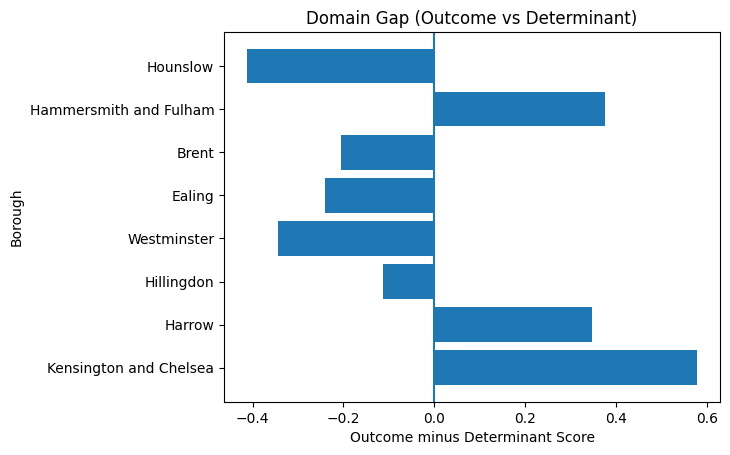

In [50]:
# Domain gap chart
plot_df = df_borough_domain_gap.copy()

plt.figure()
plt.barh(plot_df["area_name"], plot_df["outcome_minus_determinant"])

plt.xlabel("Outcome minus Determinant Score")
plt.ylabel("Borough")
plt.title("Domain Gap (Outcome vs Determinant)")

plt.axvline(0)
plt.gca().invert_yaxis()

plt.show()

How to read the domain gap results:  

- positive outcome_minus_determinant: 
-- outcomes look worse than determinants
-- may suggest service burden / disease burden is more pronounced

- negative outcome_minus_determinant:
-- determinants look worse than outcomes
-- may suggest stronger structural / social drivers

This is still descriptive, but it is much closer to the project aim.



### The above results already answer part of our core project questions: 

Are there differences across boroughs, and can we start to explain why?

1. Two distinct inequality patterns: 

#### Determinant-driven inequality - structural conditions (housing, employment, environment) are worse: 
- Hounslow
- Brent
- Ealing
- Westminster

This is important for:
- prevention
- VCSE upstream interventions

#### Outcome-driven inequality - suggests service-related factors (access, experience, outcome), population complexity, or unmet need
- Hammersmith and Fulham

This is important for:
- access
- service experience
- targeted care

#### Relatively lower inequality - comparatively better position (but still requires subgroup analysis)
- Kensington and Chelsea
- Harrow

2. Key insight for the project:

- Hounslow - structural disadvantage - requires prevention focus 
- Brent - structural + emerging outcomes - high priority
- H&F - outcome pressure - service access/delivery
- Westminster - hidden structural risk 
- Ealing - moderate structural pressure 

### Now we will bring the most important layer for the project - ethnicity exposure (Black population proportion)

In [51]:
# Extract Black population share
df_black_population = (
    df_population_prop
    .loc[df_population_prop["ethnicity_standard"] == "Black"]
    .copy()
)

df_black_population = df_black_population.rename(
    columns={"population_proportion": "black_population_share"}
)

df_black_population = df_black_population[
    ["area_name", "black_population_share"]
]

df_black_population

,area_name,black_population_share
1,Brent,0.175077
6,Ealing,0.107571
11,Hammersmith and Fulham,0.122589
16,Harrow,0.073318
21,Hillingdon,0.078308
26,Hounslow,0.072212
31,Kensington and Chelsea,0.078669
36,Westminster,0.080573


In [52]:
# Combine inequality with ethnicity
df_inequality_ethnicity = borough_domain_profile_df.merge(
    df_black_population,
    on="area_name",
    how="left"
)

df_inequality_ethnicity = df_inequality_ethnicity.sort_values(
    "inequality_score",
    ascending=False
).reset_index(drop=True)

df_inequality_ethnicity

,area_name,determinant_inequality_score,outcome_inequality_score,inequality_score,black_population_share
0,Hounslow,0.496094,0.082825,0.147269,0.072212
1,Hammersmith and Fulham,-0.179528,0.196647,0.130513,0.122589
2,Brent,0.289348,0.083009,0.113759,0.175077
3,Ealing,0.238457,-0.002655,0.034051,0.107571
4,Westminster,0.293649,-0.049637,0.008946,0.080573
5,Hillingdon,0.062285,-0.050932,-0.033353,0.078308
6,Harrow,-0.487593,-0.140849,-0.196186,0.073318
7,Kensington and Chelsea,-0.715137,-0.135980,-0.246640,0.078669


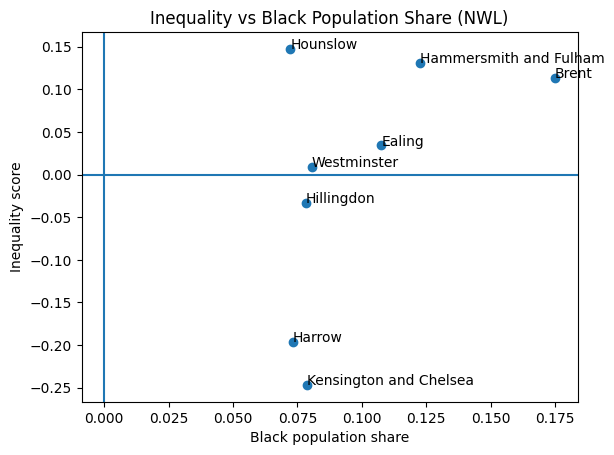

In [53]:
# visual: inequality vs Black population
plt.figure()

plt.scatter(
    df_inequality_ethnicity["black_population_share"],
    df_inequality_ethnicity["inequality_score"]
)

for _, row in df_inequality_ethnicity.iterrows():
    plt.text(
        row["black_population_share"],
        row["inequality_score"],
        row["area_name"]
    )

plt.xlabel("Black population share")
plt.ylabel("Inequality score")
plt.title("Inequality vs Black Population Share (NWL)")

plt.axhline(0)
plt.axvline(0)

plt.show()

### Key insight: Inequality vs Black population share (NWL)

#### TOP-RIGHT (high inequality + higher Black population share) - CORE PROJECT INSIGHT 
- Brent
- Hammersmith and Fulham

These boroughs combine higher overall inequality with higher exposure of Black communities → priority areas for equity-focused work.

This aligns directly with:
- targeting VCSE interventions
- prioritising community engagement
- focusing ICB partnership discussions

#### UPPER-MID (high inequality, moderate Black population):
- Hounslow

High structural inequality but lower relative Black population share. Suggests broader deprivation drivers rather than ethnicity concentration alone.

#### MIDDLE (near average inequality):
- Ealing
- Westminster

Mixed picture:
  - Ealing → moderate Black population + moderate inequality
  - Westminster → structural determinants high but outcomes lower
  → potential hidden or emerging risks.

#### LOWER (lower inequality):
- Hillingdon
- Harrow
- Kensington and Chelsea

Lower overall inequality, even where Black population share is moderate.

Important for identifying:
- protective factors
- service/system differences

--------------------------------------------------
#### CRITICAL NUANCE

- High inequality does NOT automatically equal ethnicity-driven inequality
- But where both co-occur, risk of unequal impact is higher

This part of the project (including plot) indicates where to investigate deeper, not final causality

We now have the first equity-targeting lens, not just “which borough is worse” but: where inequality and population exposure intersect

### NEXT STEP 

Move from borough-level exposure to: what is driving inequality in those high-risk boroughs.

Specifically, we will focus on 
- Brent
- Hammersmith and Fullham
- Hounslow

We will look at answering: Are inequalities driven more by health outcomes? wider determinants? or both? 

In [54]:
# Priority borough subset
priority_boroughs = [
    "Brent",
    "Hammersmith and Fulham",
    "Hounslow"
]

df_priority = df_direction[
    df_direction["area_name"].isin(priority_boroughs)
].copy()

df_priority.head()

,area_name,area_code,metric,model_year,model_time,category,measure_raw,value,data_source,value_type,metric_mean,metric_std,z_score,direction,adjusted_z_score
0,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2006,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
1,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2007,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
2,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2008,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
3,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2009,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN
4,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2010,NaN,NaN,NaN,NaN,NaN,percentage,26.258208,4.512572,NaN,adverse,NaN


In [55]:
# Domain breakdown (priority boroughs)
priority_domain_df = (
    df_priority
    .dropna(subset=["adjusted_z_score"])
    .groupby(["area_name", "data_source"], as_index=False)["adjusted_z_score"]
    .mean()
    .rename(columns={"adjusted_z_score": "score"})
)

priority_domain_df

,area_name,data_source,score
0,Brent,determinant,0.289348
1,Brent,outcome,0.083009
2,Hammersmith and Fulham,determinant,-0.179528
3,Hammersmith and Fulham,outcome,0.196647
4,Hounslow,determinant,0.496094
5,Hounslow,outcome,0.082825


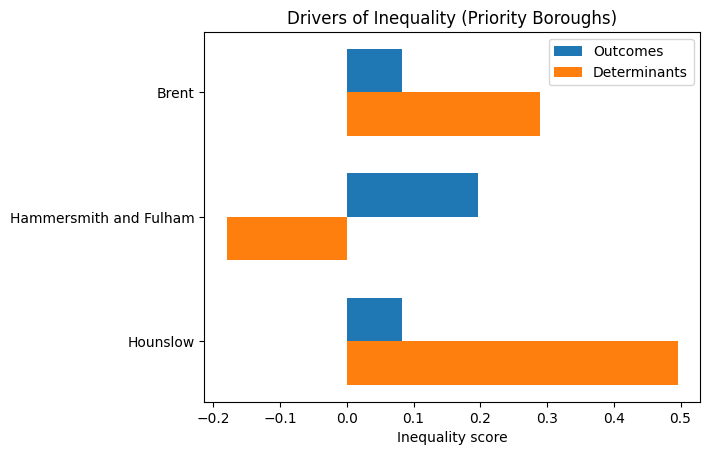

In [56]:
# Visual: outcomes vs determinants (priority)
plot_df = priority_domain_df.copy()

pivot_df = plot_df.pivot(
    index="area_name",
    columns="data_source",
    values="score"
).reset_index()

x = np.arange(len(pivot_df))
width = 0.35

plt.figure()

plt.barh(x - width/2, pivot_df["outcome"], height=width, label="Outcomes")
plt.barh(x + width/2, pivot_df["determinant"], height=width, label="Determinants")

plt.yticks(x, pivot_df["area_name"])
plt.xlabel("Inequality score")
plt.title("Drivers of Inequality (Priority Boroughs)")
plt.legend()

plt.gca().invert_yaxis()

plt.show()

In [57]:
# Identify which specific indicators are driving inequality
top_drivers_df = (
    df_priority
    .dropna(subset=["adjusted_z_score"])
    .groupby(["area_name", "metric"], as_index=False)["adjusted_z_score"]
    .mean()
)

top_drivers_df = top_drivers_df.sort_values(
    ["area_name", "adjusted_z_score"],
    ascending=[True, False]
)

# Top 5 drivers per borough
top_drivers_df = (
    top_drivers_df
    .groupby("area_name")
    .head(5)
    .reset_index(drop=True)
)

top_drivers_df

,area_name,metric,adjusted_z_score
0,Brent,Estimated prevalence of diagnosed and undiagnosed type 2 diabetes,1.181175
1,Brent,3. Low Birth Weight,0.824996
2,Brent,5. Excess weight age 10-11,0.771515
3,Brent,Access rate to specialist perinatal mental health services,0.705242
4,Brent,11. HIV late diagnosis,0.695242
5,Hammersmith and Fulham,Cancer incidence: lung cancer,2.158301
6,Hammersmith and Fulham,Chronic obstructive pulmonary disease (COPD): emergency hospital admissions,1.966605
7,Hammersmith and Fulham,% reporting a long-term mental health problem,1.728301
8,Hammersmith and Fulham,Chlamydia proportion of females aged 15 to 24 years screened,1.683853
9,Hammersmith and Fulham,% with caring responsibility,1.588188


### A couple of notes:

The distinction between outcomes and determinants is based on dataset source (Fingertips vs GLA) and should be interpreted as a pragmatic analytical grouping rather than a strict causal classification.

Healthy life expectatncy (HLE) in Hounslow for female and male is below the NWL average, contributing to overall inequality. It is expressed as a z-score after standardisation (not percentages) 

### Priority borough deep-dive — drivers of inequality

1. Hounslow → Strong determinant-driven inequality

- Determinant score is substantially higher than outcomes
- Top drivers include:
  - HIV late diagnosis
  - Lower healthy life expectancy (male & female)
  - School readiness (FSM)
- Interpretation:
  Structural and social conditions are the dominant drivers
- Implication:
  Focus on prevention, early intervention, and wider determinants (housing, education, income)

--------------------------------------------------

2. Brent → Mixed but determinant-leaning inequality
- Determinants clearly higher than outcomes
- Top drivers:
  - Type 2 diabetes prevalence
  - Low birth weight
  - Childhood excess weight
  - HIV late diagnosis
- Interpretation:
  Strong overlap between:
  - metabolic health risks
  - maternal/child health
- Combined with highest Black population share → critical equity focus area
- Implication:
  Integrated approach:
  - prevention (diet, obesity, maternal health)
  - targeted outreach for Black communities
  - VCSE role likely significant

--------------------------------------------------

3. Hammersmith and Fulham → Outcome-driven inequality
- Outcomes high, determinants below average
- Top drivers:
  - Lung cancer incidence
  - COPD emergency admissions
  - Mental health problems
  - Screening-related indicators
- Interpretation:
  Inequality likely driven by:
  - service access
  - unmet need
  - late diagnosis patterns
- Implication:
  Focus on:
  - access to care
  - early diagnosis
  - service experience
  - targeted clinical interventions

--------------------------------------------------

CROSS-BOROUGH INSIGHT

Different inequality mechanisms are operating:

- Hounslow → structural inequality
- Brent → structural + health risk accumulation
- H&F → service / outcome inequality

This directly supports:

→ No single intervention model
→ Need for borough-specific strategies

--------------------------------------------------

LINK TO PROJECT AIM

For Black and African Caribbean communities:

- Brent stands out as highest combined risk:
  - high inequality
  - highest Black population share
  - strong metabolic and maternal health signals

- Hounslow:
  - high inequality but lower Black population share
  → broader deprivation lens

- Hammersmith & Fulham:
  - outcome inequality suggests potential access barriers
  → requires service-focused investigation

--------------------------------------------------

NEXT ANALYTICAL STEP

To strengthen the evidence base:

We will bring in service experience (GPPS)

We will check whether:
   - high outcome inequality aligns with poorer experience
   - particularly in Hammersmith & Fulham

This connects inequality to:
  - access
  - patient experience 
  - system performance 
  
This is directly aligned with the project aims 

IMPORTANT CONSTRAINT 

GPPS data is at ICS level not borough.

We will use ICS as a contextual proxy 

We will compare NWL borough inequality vs ICS-level service experience. 

This is not ideal but with the absenceof data, this approach is analytically valid.



In [58]:
# GPPS experience summary
df_gpps = df_gpps_experience.copy()

# Keep only relevant columns
df_gpps = df_gpps[
    ["area_name", "metric", "response_category", "value"]
]

# Convert response_category to numeric (defensive)
df_gpps["response_category"] = pd.to_numeric(
    df_gpps["response_category"],
    errors="coerce"
)

# Create weighted experience score
df_gpps["weighted_score"] = (
    df_gpps["response_category"] * df_gpps["value"]
)

gpps_summary_df = (
    df_gpps
    .groupby("area_name", as_index=False)
    .agg(
        total_score=("weighted_score", "sum"),
        total_weight=("value", "sum")
    )
)

gpps_summary_df["experience_score"] = (
    gpps_summary_df["total_score"] / gpps_summary_df["total_weight"]
)

gpps_summary_df

,area_name,total_score,total_weight,experience_score
0,"BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE SYSTEM",5.886092,3.028422,1.943617
1,"BEDFORDSHIRE, LUTON AND MILTON KEYNES INTEGRATED CARE SYSTEM",6.985388,3.043383,2.295270
2,BIRMINGHAM AND SOLIHULL INTEGRATED CARE SYSTEM,6.924818,3.052671,2.268445
3,BLACK COUNTRY INTEGRATED CARE SYSTEM,6.768310,3.047004,2.221300
4,"BRISTOL, NORTH SOMERSET AND SOUTH GLOUCESTERSHIRE INTEGRATED CARE SYSTEM",6.321426,3.032441,2.084599
5,"BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE WEST INTEGRATED CARE SYSTEM",6.214596,3.030271,2.050838
6,CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED CARE SYSTEM,6.372773,3.037455,2.098063
7,CHESHIRE AND MERSEYSIDE INTEGRATED CARE SYSTEM,6.239778,3.033889,2.056693
8,CORNWALL AND THE ISLES OF SCILLY INTEGRATED CARE SYSTEM,6.149375,3.029561,2.029791
9,COVENTRY AND WARWICKSHIRE INTEGRATED CARE SYSTEM,6.030735,3.037280,1.985571


Explanation: 

- response_category

Typically:

1 = very poor
5 = very good

- total_score

sum(response_category × proportion)

→ weighted sum of responses
→ captures both distribution and sentiment

- total_weight

sum(proportion)

→ should be ≈ number of questions / metrics combined
→ acts as a normalising denominator

- experience_score

total_score / total_weight

→ average response score (1–5 scale)

So:

NWL ICS = ~2.11
positioned roughly mid-range nationally

not worst, not best

So:

system experience is not collapsing, but not strong either

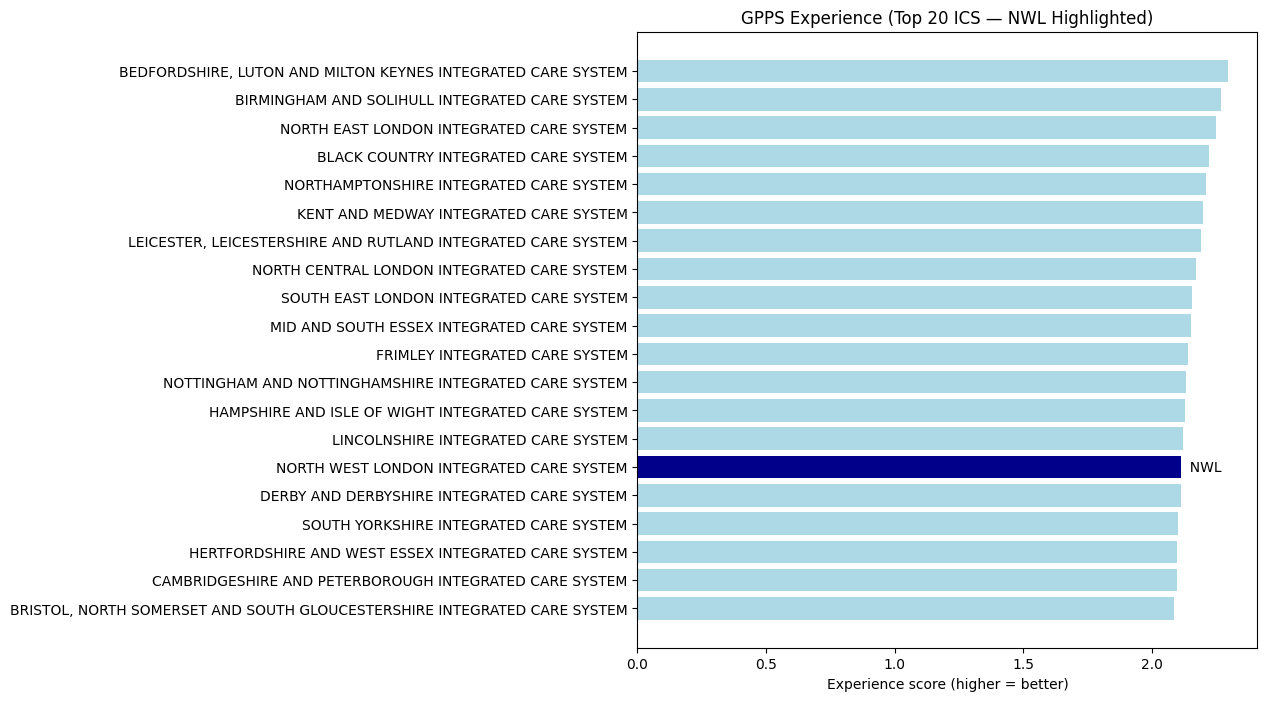

In [66]:
# GPPS experience (top 20 ICS out of 42)
plot_df = (
    gpps_summary_df
    .sort_values("experience_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Identify NWL
plot_df["is_nwl"] = plot_df["area_name"].str.contains("NORTH WEST LONDON")

plt.figure(figsize=(8, 8))

# Colour scheme
colors = [
    "darkblue" if is_nwl else "lightblue"
    for is_nwl in plot_df["is_nwl"]
]

plt.barh(
    plot_df["area_name"],
    plot_df["experience_score"],
    color=colors
)

# Optional: label NWL
for i, row in plot_df.iterrows():
    if row["is_nwl"]:
        plt.text(
            row["experience_score"],
            i,
            "  NWL",
            va="center"
        )

plt.xlabel("Experience score (higher = better)")
plt.title("GPPS Experience (Top 20 ICS — NWL Highlighted)")

plt.gca().invert_yaxis()

plt.show()

We now have: 

Borough-level outcome inequality (high in H&F)

System-level experience (mid-tier NWL, ranking 15 out 42)

This allows a grounded statement:

Outcomes are relatively worse in parts of NWL, while patient experience is only average. 

This suggests gaps in access, responsiveness, or system effectiveness that does not support improvemnet of health outcomes.

Now we build a synthesis layer that brings together:

- borough outcome inequality
- overall borough inequality
- Black population share
- NWL system experience context

Because GPPS is ICS-level, this is a context overlay, not a borough-level causal join.

In [ ]:
# Create NWL service experience context table.
# Extract NWL ICS experience score as a contextual benchmark.
nwl_experience_df = (
    gpps_summary_df[
        gpps_summary_df["area_name"] == "NORTH WEST LONDON INTEGRATED CARE SYSTEM"
    ]
    .copy()
)

nwl_experience_df

,area_name,total_score,total_weight,experience_score
29,NORTH WEST LONDON INTEGRATED CARE SYSTEM,6.461753,3.056846,2.113863


In [68]:
# Create borough synthesis table.
# Combine key borough signals into one interpretable table.
nwl_experience_score = nwl_experience_df["experience_score"].iloc[0]

borough_synthesis_df = (
    df_inequality_ethnicity[
        [
            "area_name",
            "determinant_inequality_score",
            "outcome_inequality_score",
            "inequality_score",
            "black_population_share",
        ]
    ]
    .copy()
)

borough_synthesis_df["nwl_ics_experience_score"] = nwl_experience_score

borough_synthesis_df = borough_synthesis_df.sort_values(
    "inequality_score",
    ascending=False
).reset_index(drop=True)

borough_synthesis_df


,area_name,determinant_inequality_score,outcome_inequality_score,inequality_score,black_population_share,nwl_ics_experience_score
0,Hounslow,0.496094,0.082825,0.147269,0.072212,2.113863
1,Hammersmith and Fulham,-0.179528,0.196647,0.130513,0.122589,2.113863
2,Brent,0.289348,0.083009,0.113759,0.175077,2.113863
3,Ealing,0.238457,-0.002655,0.034051,0.107571,2.113863
4,Westminster,0.293649,-0.049637,0.008946,0.080573,2.113863
5,Hillingdon,0.062285,-0.050932,-0.033353,0.078308,2.113863
6,Harrow,-0.487593,-0.140849,-0.196186,0.073318,2.113863
7,Kensington and Chelsea,-0.715137,-0.135980,-0.246640,0.078669,2.113863


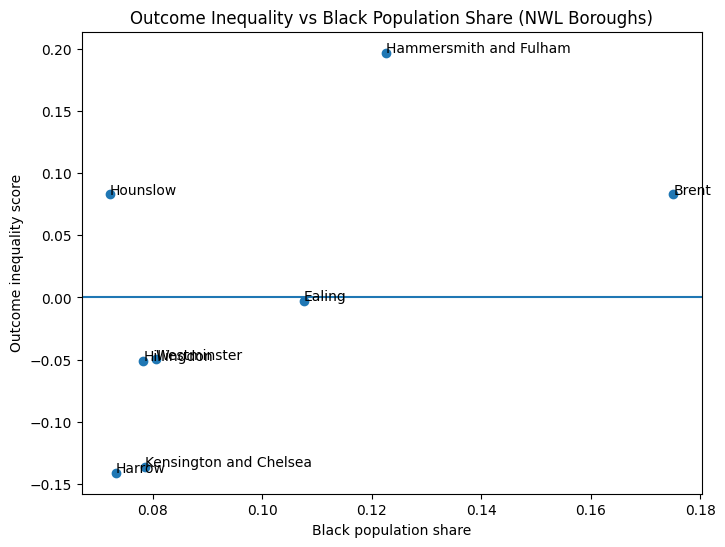

In [ ]:
# Outcome inequality vs Black population share
plot_df = borough_synthesis_df.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["black_population_share"],
    plot_df["outcome_inequality_score"]
)

for _, row in plot_df.iterrows():
    plt.text(
        row["black_population_share"],
        row["outcome_inequality_score"],
        row["area_name"]
    )

plt.xlabel("Black population share")
plt.ylabel("Outcome inequality score")
plt.title("Outcome Inequality vs Black Population Share (NWL Boroughs)")

plt.axhline(0)
plt.show()

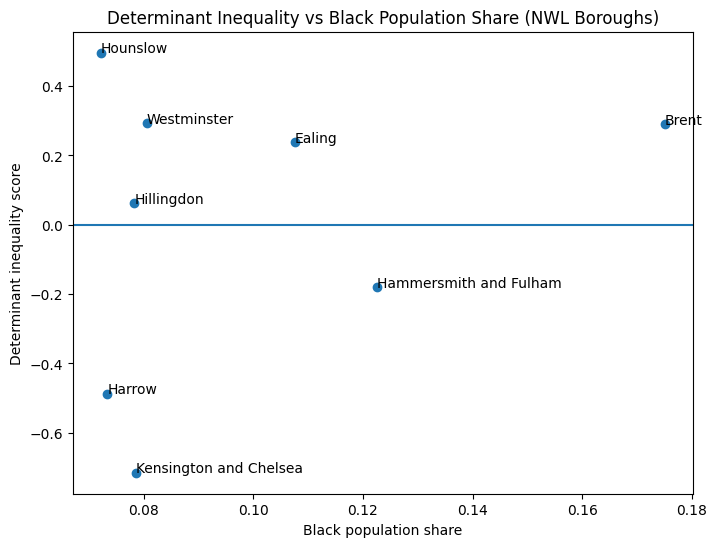

In [70]:
# Determinant inequality vs Black population share.
# Distinguish structural exposure from outcome exposure.
plot_df = borough_synthesis_df.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["black_population_share"],
    plot_df["determinant_inequality_score"]
)

for _, row in plot_df.iterrows():
    plt.text(
        row["black_population_share"],
        row["determinant_inequality_score"],
        row["area_name"]
    )

plt.xlabel("Black population share")
plt.ylabel("Determinant inequality score")
plt.title("Determinant Inequality vs Black Population Share (NWL Boroughs)")

plt.axhline(0)
plt.show()

### Synthesis summary: Outcomes, determinants, and Black population exposure

1. Outcome inequality vs Black population share

- Hammersmith and Fulham:

  Highest outcome inequality, moderate Black population share - Strong signal of service-related or unmet clinical need

- Brent:

  High Black population share + positive outcome inequality - High-risk intersection (core priority for project)

- Hounslow:

  Moderate outcome inequality, lower Black population share - Outcomes present but less ethnicity-concentrated

- Ealing / Westminster:

  Around average or slightly negative outcomes - No strong outcome signal despite moderate population share

--------------------------------------------------

2. Determinant inequality vs Black population share

- Hounslow:

  Very high determinant inequality, lower Black population share - Structural disadvantage, but less concentrated in Black population

- Brent:

  High determinant inequality + highest Black population share - Strong structural inequality exposure for Black communities

- Ealing / Westminster:

  Moderate determinant inequality - Emerging structural pressures

- Hammersmith and Fulham:

  Negative determinant score - Structural conditions comparatively better

--------------------------------------------------

3. Combined interpretation (key project insight)

Brent:
- High Black population share
- High determinant inequality
- Positive outcome inequality
→ Strongest overall equity concern
→ Likely requires:
   - prevention
   - structural interventions
   - community-led VCSE work

Hammersmith and Fulham:
- High outcome inequality
- Lower determinant inequality
→ Suggests:
   - access barriers
   - late diagnosis
   - service pathway issues

Hounslow:
- High determinant inequality
- Moderate outcomes
→ Upstream drivers dominant
→ Prevention and social policy important

--------------------------------------------------

4. System context (GPPS)

- NWL ICS experience score ≈ 2.11 (mid-range nationally)
- Interpretation - System experience is not poor, but not strong

- Combined insight:
  Moderate system experience + high outcome inequality (H&F)
  → suggests experience alone is not sufficient to offset inequality possible gaps in access, targeting, or effectiveness

--------------------------------------------------

5. Strategic implications

Priority areas:

- Brent:
  Intersection of:
  - ethnicity exposure
  - structural inequality
  - health outcomes

- Hammersmith and Fulham:
  Outcome-driven inequality → service access focus

- Hounslow:
  Structural inequality → prevention and determinants

This supports:
- targeted VCSE engagement
- borough-specific strategies
- evidence-based advocacy with ICB

--------------------------------------------------

This is an evidence-building step, not causal proof.

Further work will explore:
- time trends
- service-specific access metrics
- community-level variation


### Next 

we will proceed with Time trends of inequality (borough level). 

This will allow us to say - not just where inequality exists, but whethere it is getting worse  

In [71]:
# Prepare time-series dataset
# Keep only valid time + scores for trend analysis.
df_time = (
    df_direction
    .dropna(subset=["adjusted_z_score", "model_year"])
    .copy()
)

# Ensure correct types
df_time["model_year"] = pd.to_numeric(df_time["model_year"], errors="coerce")

df_time = df_time.dropna(subset=["model_year"])

df_time.head()

,area_name,area_code,metric,model_year,model_time,category,measure_raw,value,data_source,value_type,metric_mean,metric_std,z_score,direction,adjusted_z_score
8,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2014,2014/15,NaN,value,25.987533,outcome,percentage,26.258208,4.512572,-0.059982,adverse,-0.059982
9,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2015,2015/16,NaN,value,26.395159,outcome,percentage,26.258208,4.512572,0.030349,adverse,0.030349
10,Brent,E09000005,% reporting a long term MSK problem who also report depression or anxiety,2016,2016/17,NaN,value,23.705820,outcome,percentage,26.258208,4.512572,-0.565617,adverse,-0.565617
33,Brent,E09000005,% reporting a long-term mental health problem,2020,2020,NaN,value,6.391032,outcome,percentage,8.437101,2.910865,-0.702907,adverse,-0.702907
52,Brent,E09000005,% reporting cancer in the last 5 years,2020,2020,NaN,value,2.793530,outcome,percentage,2.382675,0.676442,0.607377,adverse,0.607377


In [73]:
# Borough-level yearly inequality
# Compute yearly inequality score per borough
borough_time_df = (
    df_time
    .groupby(["area_name", "model_year"], as_index=False)["adjusted_z_score"]
    .mean()
    .rename(columns={"adjusted_z_score": "yearly_inequality_score"})
)

borough_time_df.head()

,area_name,model_year,yearly_inequality_score
0,Brent,2006,1.623696
1,Brent,2007,0.602821
2,Brent,2008,0.535990
3,Brent,2009,0.174776
4,Brent,2010,0.450892


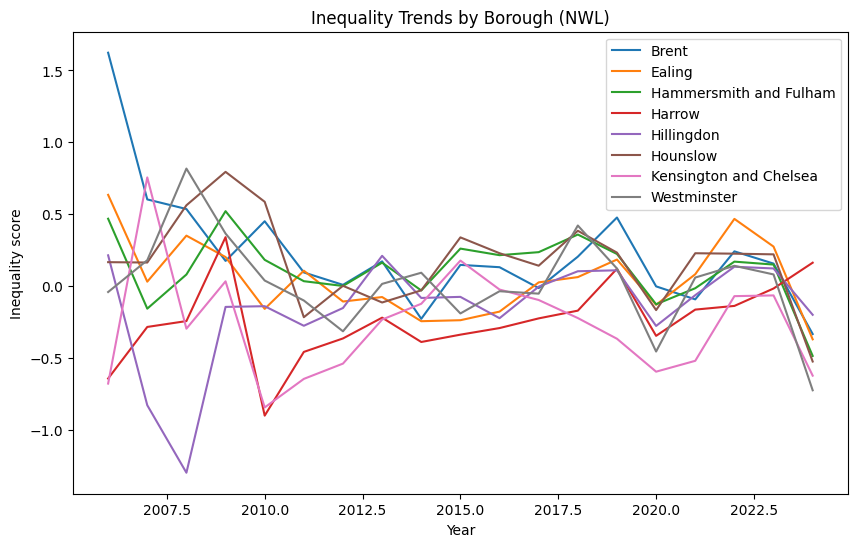

In [74]:
# Visual: inequality trends (all boroughs)
# Compare trends across boroughs

plt.figure(figsize=(10, 6))

for borough in borough_time_df["area_name"].unique():
    subset = borough_time_df[borough_time_df["area_name"] == borough]
    
    plt.plot(
        subset["model_year"],
        subset["yearly_inequality_score"],
        label=borough
    )

plt.xlabel("Year")
plt.ylabel("Inequality score")
plt.title("Inequality Trends by Borough (NWL)")

plt.legend()
plt.show()

### NOTE
We will now look at Borough groups. They were grouped based on their relative inequality burden and underlying drivers, rather than simple high–low rankings

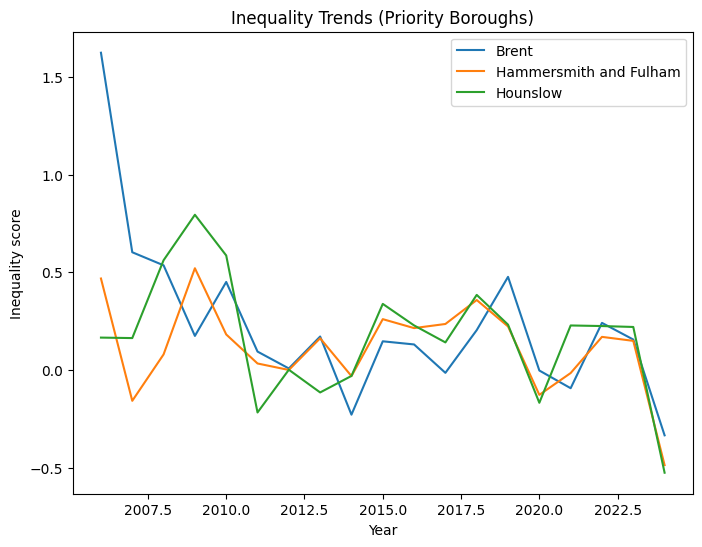

In [75]:
# Visual: priority borough trends
# Clearer view for key boroughs
priority_boroughs = ["Brent", "Hammersmith and Fulham", "Hounslow"]

plot_df = borough_time_df[
    borough_time_df["area_name"].isin(priority_boroughs)
]

plt.figure(figsize=(8, 6))

for borough in priority_boroughs:
    subset = plot_df[plot_df["area_name"] == borough]
    
    plt.plot(
        subset["model_year"],
        subset["yearly_inequality_score"],
        label=borough
    )

plt.xlabel("Year")
plt.ylabel("Inequality score")
plt.title("Inequality Trends (Priority Boroughs)")

plt.legend()
plt.show()

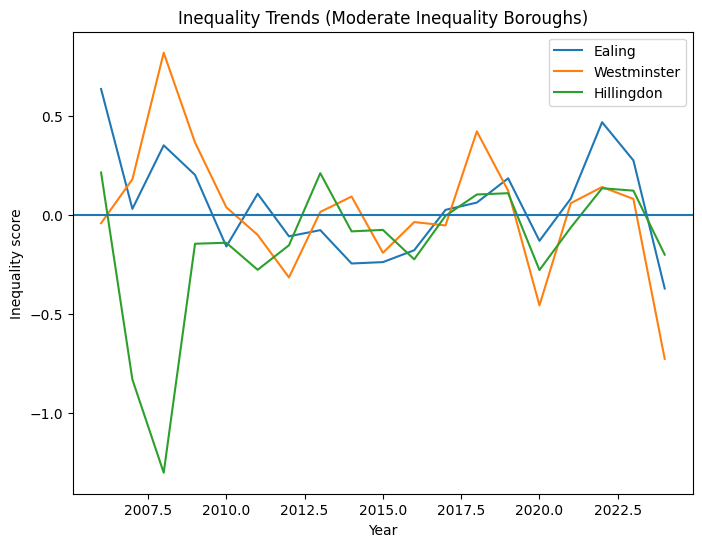

In [80]:
# Inequality trends (moderate/mixed inequality boroughs)
middle_boroughs = ["Ealing", "Westminster", "Hillingdon"]

plot_df = borough_time_df[
    borough_time_df["area_name"].isin(middle_boroughs)
]

plt.figure(figsize=(8, 6))

for borough in middle_boroughs:
    subset = plot_df[plot_df["area_name"] == borough]
    
    plt.plot(
        subset["model_year"],
        subset["yearly_inequality_score"],
        label=borough
    )

plt.xlabel("Year")
plt.ylabel("Inequality score")
plt.title("Inequality Trends (Moderate Inequality Boroughs)")

plt.axhline(0)
plt.legend()
plt.show()

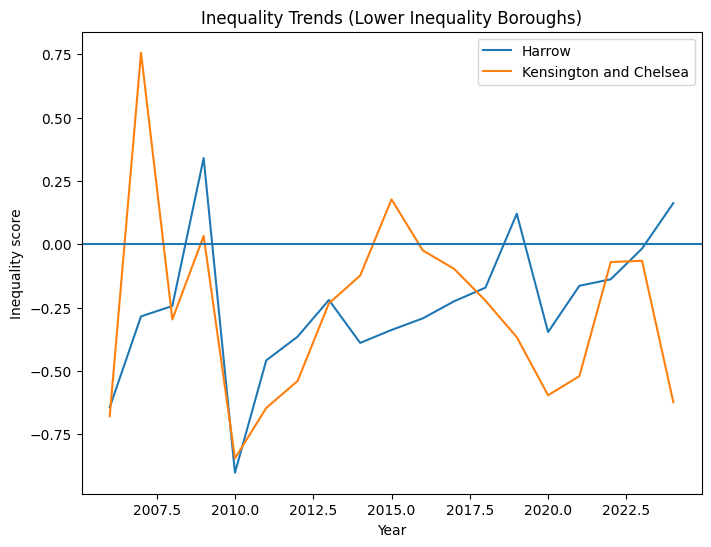

In [81]:
# Inequality trends (Lower inequality boroughs)
lower_boroughs = ["Harrow", "Kensington and Chelsea"]

plot_df = borough_time_df[
    borough_time_df["area_name"].isin(lower_boroughs)
]

plt.figure(figsize=(8, 6))

for borough in lower_boroughs:
    subset = plot_df[plot_df["area_name"] == borough]
    
    plt.plot(
        subset["model_year"],
        subset["yearly_inequality_score"],
        label=borough
    )

plt.xlabel("Year")
plt.ylabel("Inequality score")
plt.title("Inequality Trends (Lower Inequality Boroughs)")

plt.axhline(0)
plt.legend()
plt.show()

In [77]:
# Trend summary (simple slope proxy)
# Quantify direction of change
trend_summary_df = (
    borough_time_df
    .sort_values(["area_name", "model_year"])
    .groupby("area_name")
    .agg(
        start_score=("yearly_inequality_score", "first"),
        end_score=("yearly_inequality_score", "last")
    )
    .reset_index()
)

trend_summary_df["change"] = (
    trend_summary_df["end_score"] - trend_summary_df["start_score"]
)

trend_summary_df = trend_summary_df.sort_values(
    "change",
    ascending=False
).reset_index(drop=True)

trend_summary_df

,area_name,start_score,end_score,change
0,Harrow,-0.643640,0.162462,0.806102
1,Kensington and Chelsea,-0.678829,-0.623534,0.055295
2,Hillingdon,0.213774,-0.200172,-0.413946
3,Westminster,-0.041637,-0.725409,-0.683772
4,Hounslow,0.166173,-0.525192,-0.691365
5,Hammersmith and Fulham,0.468462,-0.486216,-0.954678
6,Ealing,0.634636,-0.370847,-1.005483
7,Brent,1.623696,-0.333860,-1.957557


### Trends  aand change table analysis 

1. High-burden boroughs (Brent, Hammersmith and Fulham, Hounslow)

Brent:
- Starts extremely high (~1.6)
- Strong downward trajectory over time
- Ends below average

→ Interpretation:
- Largest improvement across NWL
- Likely reflects:
  - system response
  - improved outcomes or determinants
  - or relative improvement vs other boroughs
- Still remains high priority due to:
  - high Black population exposure
  - structural inequality signals

Hammersmith and Fulham:
- Starts high, ends well below average
- Consistent long-term decline

→ Interpretation:
- Outcome-driven inequality has reduced
- Suggests improvements in:
  - access
  - diagnosis
  - treatment pathways

Hounslow:
- Starts above average
- Gradual decline, but more volatile

→ Interpretation:
- Structural (determinant-driven) inequality improving
- Still fluctuates → underlying pressures persist

--------------------------------------------------

2. Moderate burden boroughs (Ealing, Westminster, Hillingdon)

Ealing:
- Starts high, declines significantly
- Crosses below average

→ Interpretation:
- Clear improvement trajectory
- Now closer to balanced position

Westminster:
- Moderate early inequality
- Sharp decline to strongly negative values

→ Interpretation:
- Strong relative improvement
- However:
  - may reflect relative shift vs other boroughs
  - not necessarily absolute improvement

Hillingdon:
- Mild positive to negative trend
- Relatively stable around zero

→ Interpretation:
- No strong persistent inequality signal
- Likely balanced but sensitive to fluctuations

--------------------------------------------------

3. Lower inequality boroughs (Harrow, Kensington and Chelsea)

Harrow:
- Starts very low (strong advantage)
- Steady upward trend
- Ends above average

→ Interpretation:
- Most important emerging risk
- Transition from:
  low inequality → worsening inequality
- Requires early attention before escalation

Kensington and Chelsea:
- Consistently low (negative scores)
- Some volatility, but remains below average

→ Interpretation:
- Structurally advantaged position
- However:
  - instability suggests pockets of risk
  - not uniformly protected

--------------------------------------------------

4. Cross-borough dynamics (key insight)

Across all three visuals:

- Convergence pattern:
  Most boroughs move toward the average (0 line)

→ Interpretation:
- Inequality gaps narrowing overall
- But NOT necessarily due to universal improvement

Two possible explanations:
1. Genuine system-wide improvement
2. Relative redistribution (some improve, others worsen)

--------------------------------------------------

5. Emerging vs persistent inequality

Persistent (historical burden):
- Brent (now improving but still important)
- Hounslow (structural drivers remain)

Emerging:
- Harrow (clear upward trajectory)

Stable / balanced:
- Hillingdon
- Ealing (post-improvement)

Structurally advantaged:
- Kensington and Chelsea
- Westminster (with caution)

--------------------------------------------------

6. Link to earlier findings

- Brent:
  High ethnicity exposure + strong improvement
  → potential case study for effective intervention

- Hammersmith and Fulham:
  Outcome-driven inequality improving
  → suggests service/system responsiveness

- Hounslow:
  Determinant-driven inequality persists
  → requires upstream, prevention-focused action

- Harrow:
  Rising inequality without prior high burden
  → signals early-stage structural or service shifts

--------------------------------------------------

7. Strategic implications

Different borough types require different responses:

A. High-burden improving (Brent, H&F)
→ Sustain and scale effective interventions

B. Structural inequality (Hounslow)
→ Focus on:
   - housing
   - employment
   - prevention
   - VCSE engagement

C. Emerging risk (Harrow)
→ Early intervention:
   - monitoring
   - targeted outreach
   - community engagement

D. Stable / balanced (Ealing, Hillingdon)
→ Maintain performance, monitor volatility

--------------------------------------------------

8. Key message 

Inequality across NW London is not static. 

**While several high-burden boroughs show improvement, new areas of inequality are emerging, highlighting the need for both sustained intervention and proactive monitoring.**

--------------------------------------------------

Limitations:
- Relative (z-score based)
- Metric coverage varies over time
- Does not establish causality

### NEXT 

We will now move to preventive care layer that links inequality/outcomes/early intervention vs late system reposnse.

Important constraint - the data availabledoes not have a clean 'clean preventive dataset', so we derive it from 

Fingertips metrics - we will classify relevant indicators as preventive proxies.

For example, preventive indicators: 
- screening coverage
- vaccination uptake
- early diagnosis rate
- access to preventive services
- school readiness (early life proxy)


In [82]:
# Define preventive metrics 
preventive_keywords = [
    "screen",
    "coverage",
    "vaccination",
    "immunisation",
    "early",
    "diagnosis",
    "access",
    "school readiness",
]

df_preventive = df_direction.copy()

df_preventive["is_preventive"] = df_preventive["metric"].str.lower().apply(
    lambda x: any(keyword in x for keyword in preventive_keywords)
)

df_preventive["is_preventive"].value_counts()

is_preventive
False    8109
True     1048
Name: count, dtype: int64

In [83]:
# Extract preventive dataset
df_preventive_only = df_preventive[
    df_preventive["is_preventive"]
].dropna(subset=["adjusted_z_score"])

df_preventive_only.head()

,area_name,area_code,metric,model_year,model_time,category,measure_raw,value,data_source,value_type,metric_mean,metric_std,z_score,direction,adjusted_z_score,is_preventive
141,Brent,E09000005,11. HIV late diagnosis,2021,2021 - 23,Wider determinants,value,51.376148,determinant,absolute_or_rate,41.288232,14.509932,0.695242,adverse,0.695242,True
230,Brent,E09000005,4. School readiness FSM,2021,2021/22,Wider determinants,value,60.800000,determinant,absolute_or_rate,55.618237,3.188107,1.625341,positive,-1.625341,True
231,Brent,E09000005,4. School readiness FSM,2022,2022/23,Wider determinants,value,56.710000,determinant,absolute_or_rate,55.618237,3.188107,0.342448,positive,-0.342448,True
232,Brent,E09000005,4. School readiness FSM,2023,2023/24,Wider determinants,value,57.190600,determinant,absolute_or_rate,55.618237,3.188107,0.493196,positive,-0.493196,True
233,Brent,E09000005,4. School readiness FSM,2023,2023/24,Wider determinants,value,57.190600,determinant,absolute_or_rate,55.618237,3.188107,0.493196,positive,-0.493196,True


In [84]:
# Borough preventive score - same logic as inequality, but only preventive signals 
borough_preventive_df = (
    df_preventive_only
    .groupby("area_name", as_index=False)["adjusted_z_score"]
    .mean()
    .rename(columns={"adjusted_z_score": "preventive_inequality_score"})
    .sort_values("preventive_inequality_score", ascending=False)
    .reset_index(drop=True)
)

borough_preventive_df

,area_name,preventive_inequality_score
0,Harrow,0.282478
1,Brent,0.266772
2,Hounslow,0.154179
3,Hammersmith and Fulham,0.150448
4,Ealing,0.064129
5,Hillingdon,-0.107335
6,Kensington and Chelsea,-0.356675
7,Westminster,-0.453995


In [85]:
# Merge preventive with main inequality 
borough_preventive_combined = (
    borough_preventive_df
    .merge(
        borough_synthesis_df[
            ["area_name", "inequality_score", "black_population_share"]
        ],
        on="area_name",
        how="left"
    )
)

borough_preventive_combined


,area_name,preventive_inequality_score,inequality_score,black_population_share
0,Harrow,0.282478,-0.196186,0.073318
1,Brent,0.266772,0.113759,0.175077
2,Hounslow,0.154179,0.147269,0.072212
3,Hammersmith and Fulham,0.150448,0.130513,0.122589
4,Ealing,0.064129,0.034051,0.107571
5,Hillingdon,-0.107335,-0.033353,0.078308
6,Kensington and Chelsea,-0.356675,-0.246640,0.078669
7,Westminster,-0.453995,0.008946,0.080573


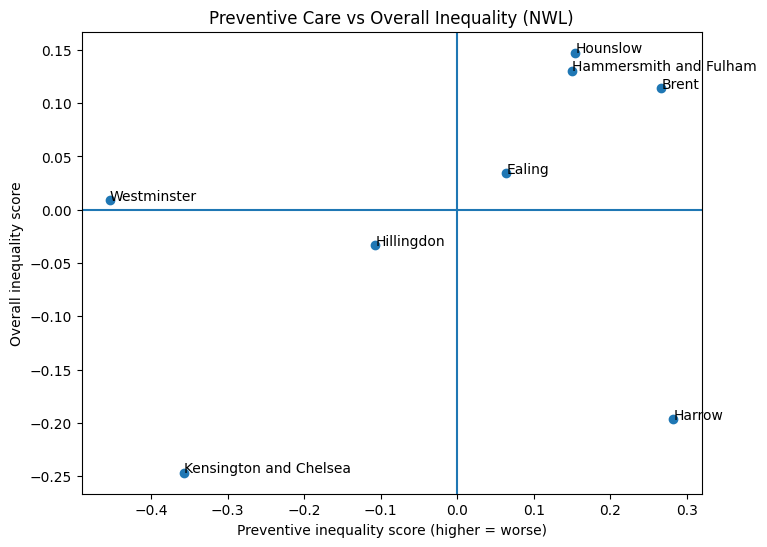

In [86]:
# Visual - preventive vs inequality
plot_df = borough_preventive_combined.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["preventive_inequality_score"],
    plot_df["inequality_score"]
)

for _, row in plot_df.iterrows():
    plt.text(
        row["preventive_inequality_score"],
        row["inequality_score"],
        row["area_name"]
    )

plt.xlabel("Preventive inequality score (higher = worse)")
plt.ylabel("Overall inequality score")
plt.title("Preventive Care vs Overall Inequality (NWL)")

plt.axhline(0)
plt.axvline(0)

plt.show()

### Preventive care vs inequality — interpretation

1. High preventive inequality + high overall inequality
(top-right quadrant)

- Brent
- Hounslow
- Hammersmith and Fulham

→ Interpretation:
- Preventive care is relatively weak
- Inequality is already high

→ This is the strongest signal of:
   missed early intervention + downstream burden

→ Brent stands out further due to:
   highest Black population share

→ Implication:
   priority for:
   - targeted outreach
   - screening uptake
   - VCSE-led engagement

--------------------------------------------------

2. High preventive inequality + low overall inequality
(top-left quadrant)

- Harrow

→ Interpretation:
- Preventive signals are worsening
- But outcomes have not yet deteriorated

→ This is an EARLY WARNING signal

→ Implication:
- opportunity to intervene before inequality becomes entrenched
- critical borough for proactive strategy

--------------------------------------------------

3. Low preventive inequality + low overall inequality
(bottom-left quadrant)

- Kensington and Chelsea

→ Interpretation:
- Strong preventive position
- Lower overall inequality

→ Suggests:
- prevention systems functioning relatively well

--------------------------------------------------

4. Low preventive inequality + mixed overall inequality
(bottom-left / centre)

- Westminster

→ Interpretation:
- Strong preventive signals
- But overall inequality ~ neutral

→ Suggests:
- prevention exists
- but may not fully translate into outcomes
  OR
- inequality driven by factors outside prevention

--------------------------------------------------

5. Transition / mixed boroughs

- Ealing:
  - Slightly positive preventive inequality
  - Slightly positive overall inequality

→ Mild pressure across both domains

- Hillingdon:
  - Negative preventive inequality (stronger prevention)
  - Slightly negative overall inequality

→ Balanced profile

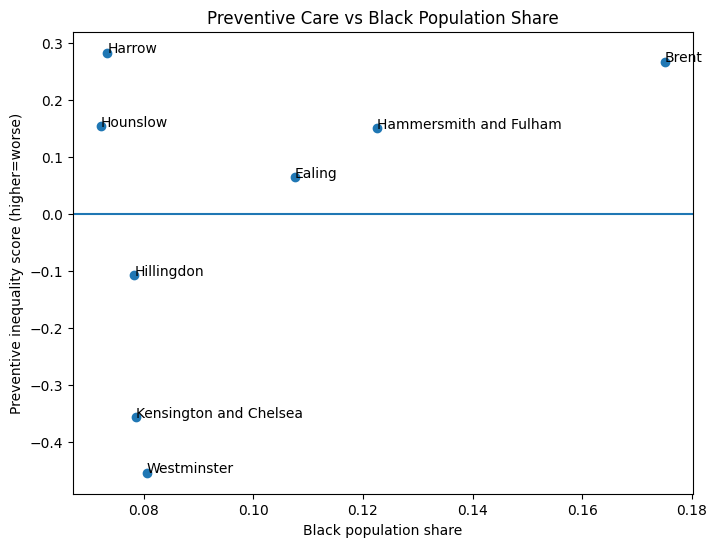

In [88]:
# Visual: Preventive vs. Black population share
plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["black_population_share"],
    plot_df["preventive_inequality_score"]
)

for _, row in plot_df.iterrows():
    plt.text(
        row["black_population_share"],
        row["preventive_inequality_score"],
        row["area_name"]
    )

plt.xlabel("Black population share")
plt.ylabel("Preventive inequality score (higher=worse)")
plt.title("Preventive Care vs Black Population Share")

plt.axhline(0)

plt.show()

### Preventive Care vs Black population share 

- Brent:
  High Black population share + high preventive inequality
  → strongest equity concern

- Hammersmith and Fulham:
  Moderate share + weak prevention
  → service access / targeting issue

- Hounslow:
  Lower share but high preventive inequality
  → broader structural issue

- Harrow:
  Lower share + rising preventive inequality
  → emerging risk, not yet ethnicity-concentrated



### Core insight

Inequality in NWL is not only about outcomes — it is strongly linked to variation in preventive care.

Different borough patterns:

- Established inequality + weak prevention → Brent, Hounslow
- Outcome-driven inequality → Hammersmith & Fulham
- Emerging prevention failure → Harrow
- Strong prevention → Kensington & Chelsea, Westminster

--------------------------------------------------

### Strategic implications 

- Brent:
  highest priority intersection:
  inequality + prevention gap + ethnicity exposure

- Hounslow:
  structural + prevention gap

- Hammersmith and Fulham:
  service pathway / access issue

- Harrow:
  early intervention opportunity

- Westminster / Kensington and Chelsea:
  benchmark / comparator boroughs

This layer moves the analysis from: "where inequality exists" to: "where inequality could have been prevented earlier"

### Finally, the actionalble layer.

#### We will now turn the evidence into a borough prioritisation framework 

In [89]:
# Borough prioritisation inputs
borough_priority_df = (
    borough_preventive_combined.merge(
        trend_summary_df[["area_name", "change"]],
        on="area_name",
        how="left"
    )
    .copy()
)

borough_priority_df = borough_priority_df.rename(
    columns={
        "change": "trend_change"
    }
)

borough_priority_df = borough_priority_df[
    [
        "area_name",
        "inequality_score",
        "preventive_inequality_score",
        "black_population_share",
        "trend_change",
    ]
].sort_values(
    "inequality_score",
    ascending=False
).reset_index(drop=True)

borough_priority_df

,area_name,inequality_score,preventive_inequality_score,black_population_share,trend_change
0,Hounslow,0.147269,0.154179,0.072212,-0.691365
1,Hammersmith and Fulham,0.130513,0.150448,0.122589,-0.954678
2,Brent,0.113759,0.266772,0.175077,-1.957557
3,Ealing,0.034051,0.064129,0.107571,-1.005483
4,Westminster,0.008946,-0.453995,0.080573,-0.683772
5,Hillingdon,-0.033353,-0.107335,0.078308,-0.413946
6,Harrow,-0.196186,0.282478,0.073318,0.806102
7,Kensington and Chelsea,-0.246640,-0.356675,0.078669,0.055295


In [90]:
# Assign borough typology and action priority -convert analytical sygnals into usable categories
borough_priority_df = borough_priority_df.copy()

def classify_borough(row):
    high_inequality = row["inequality_score"] > 0
    weak_prevention = row["preventive_inequality_score"] > 0
    high_black_share = row["black_population_share"] >= borough_priority_df["black_population_share"].median()
    worsening_trend = row["trend_change"] > 0

    if high_inequality and weak_prevention and high_black_share:
        return "High priority: equity + prevention"
    if high_inequality and weak_prevention:
        return "High priority: prevention"
    if high_inequality and not weak_prevention:
        return "High priority: outcomes/access"
    if (not high_inequality) and weak_prevention and worsening_trend:
        return "Emerging risk"
    if (not high_inequality) and not weak_prevention:
        return "Lower burden / monitor"
    return "Mixed profile / monitor"

def recommend_action(row):
    borough_type = row["borough_typology"]

    if borough_type == "High priority: equity + prevention":
        return "Targeted outreach, VCSE partnership, prevention"
    if borough_type == "High priority: prevention":
        return "Strengthen early intervention and prevention"
    if borough_type == "High priority: outcomes/access":
        return "Improve access, pathways, and service responsiveness"
    if borough_type == "Emerging risk":
        return "Early intervention and close monitoring"
    if borough_type == "Lower burden / monitor":
        return "Maintain performance and monitor"
    return "Mixed response and monitoring"

borough_priority_df["borough_typology"] = borough_priority_df.apply(
    classify_borough,
    axis=1
)

borough_priority_df["recommended_action"] = borough_priority_df.apply(
    recommend_action,
    axis=1
)

borough_priority_df

,area_name,inequality_score,preventive_inequality_score,black_population_share,trend_change,borough_typology,recommended_action
0,Hounslow,0.147269,0.154179,0.072212,-0.691365,High priority: prevention,Strengthen early intervention and prevention
1,Hammersmith and Fulham,0.130513,0.150448,0.122589,-0.954678,High priority: equity + prevention,"Targeted outreach, VCSE partnership, prevention"
2,Brent,0.113759,0.266772,0.175077,-1.957557,High priority: equity + prevention,"Targeted outreach, VCSE partnership, prevention"
3,Ealing,0.034051,0.064129,0.107571,-1.005483,High priority: equity + prevention,"Targeted outreach, VCSE partnership, prevention"
4,Westminster,0.008946,-0.453995,0.080573,-0.683772,High priority: outcomes/access,"Improve access, pathways, and service responsiveness"
5,Hillingdon,-0.033353,-0.107335,0.078308,-0.413946,Lower burden / monitor,Maintain performance and monitor
6,Harrow,-0.196186,0.282478,0.073318,0.806102,Emerging risk,Early intervention and close monitoring
7,Kensington and Chelsea,-0.246640,-0.356675,0.078669,0.055295,Lower burden / monitor,Maintain performance and monitor


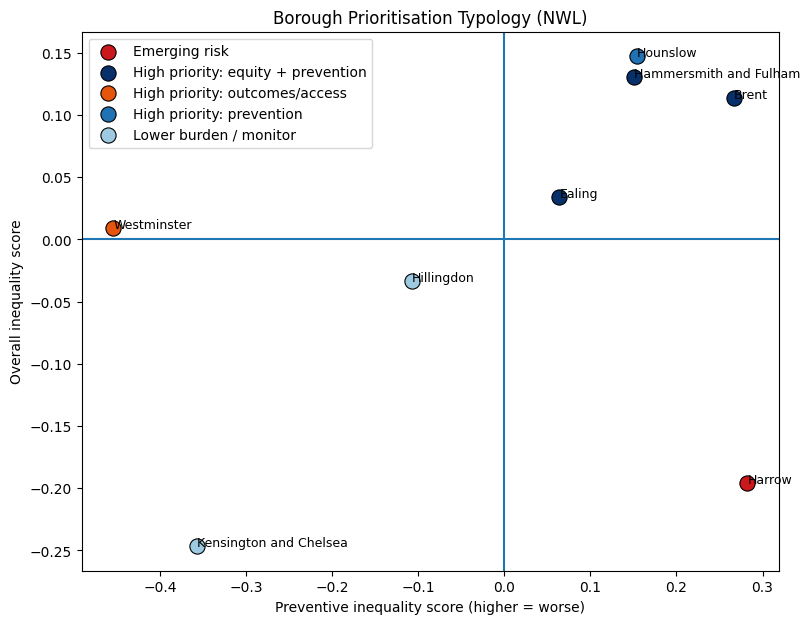

In [ ]:
# Borough prioritisation visual
plot_df = borough_priority_df.copy()

typology_colors = {
    "High priority: equity + prevention": "#08306B",   # deep navy
    "High priority: prevention": "#2171B5",           # strong blue
    "High priority: outcomes/access": "#E6550D",      # orange
    "Emerging risk": "#CB181D",                       # red
    "Lower burden / monitor": "#9ECAE1",              # light blue
    "Mixed profile / monitor": "#969696",             # grey
}

plt.figure(figsize=(9, 7))

for borough_type, subset in plot_df.groupby("borough_typology"):
    plt.scatter(
        subset["preventive_inequality_score"],
        subset["inequality_score"],
        label=borough_type,
        color=typology_colors.get(borough_type, "#969696"),
        s=120,                # larger dots
        edgecolor="black",    # improves visibility
        linewidth=0.8
    )

# Labels
for _, row in plot_df.iterrows():
    plt.text(
        row["preventive_inequality_score"],
        row["inequality_score"],
        row["area_name"],
        fontsize=9
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Preventive inequality score (higher = worse)")
plt.ylabel("Overall inequality score")
plt.title("Borough Prioritisation Typology (NWL)")

plt.legend()
plt.show()

In [93]:
# Final prioritisation table to create a clean decision-ready output.
final_priority_table_df = borough_priority_df[
    [
        "area_name",
        "borough_typology",
        "recommended_action",
        "inequality_score",
        "preventive_inequality_score",
        "black_population_share",
        "trend_change",
    ]
].sort_values(
    ["borough_typology", "inequality_score"],
    ascending=[True, False]
).reset_index(drop=True)

final_priority_table_df

,area_name,borough_typology,recommended_action,inequality_score,preventive_inequality_score,black_population_share,trend_change
0,Harrow,Emerging risk,Early intervention and close monitoring,-0.196186,0.282478,0.073318,0.806102
1,Hammersmith and Fulham,High priority: equity + prevention,"Targeted outreach, VCSE partnership, prevention",0.130513,0.150448,0.122589,-0.954678
2,Brent,High priority: equity + prevention,"Targeted outreach, VCSE partnership, prevention",0.113759,0.266772,0.175077,-1.957557
3,Ealing,High priority: equity + prevention,"Targeted outreach, VCSE partnership, prevention",0.034051,0.064129,0.107571,-1.005483
4,Westminster,High priority: outcomes/access,"Improve access, pathways, and service responsiveness",0.008946,-0.453995,0.080573,-0.683772
5,Hounslow,High priority: prevention,Strengthen early intervention and prevention,0.147269,0.154179,0.072212,-0.691365
6,Hillingdon,Lower burden / monitor,Maintain performance and monitor,-0.033353,-0.107335,0.078308,-0.413946
7,Kensington and Chelsea,Lower burden / monitor,Maintain performance and monitor,-0.246640,-0.356675,0.078669,0.055295


This table serves as a final outcome of the project, identifying health inequality priority boroughs in NW London with recommended actions, based on the anslysis of disadvantage (inequality) score, preventive score, black population share and timely trends/changes in health disadvantage areas.